# IT9115 — Adaptive Threat Detection Framework
## Metrics Chart Reporter · Jupyter Notebook Edition
> Each cell produces one **individual** publication-quality PNG  
> suitable for direct inclusion in a research journal paper.  
> All figures are saved to `charts/` at 300 DPI.

In [1]:
%matplotlib inline
import warnings, json, csv, textwrap, os
from pathlib import Path
from datetime import datetime

warnings.filterwarnings("ignore")

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyBboxPatch
from matplotlib.ticker import MaxNLocator
import numpy as np

from IPython.display import display, Image as IPyImage

print("Matplotlib:", matplotlib.__version__)
print("NumPy     :", np.__version__)

Matplotlib: 3.10.6
NumPy     : 2.3.5


## Configuration

In [2]:
# ── Paths ────────────────────────────────────────────────────────────────────
RESULTS_JSON = "results.json"
CSV_PREFIX   = "results"        # -> results_mttd.csv, results_alerts.csv ...
OUTPUT_DIR   = Path("charts")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ── Publication quality ───────────────────────────────────────────────────────
DPI          = 300              # 300 dpi for journal submission
WATERMARK    = True             # set False to remove watermark text
SHOW_INLINE  = True             # display figure inline after saving

print(f"Output directory : {OUTPUT_DIR.resolve()}")
print(f"DPI              : {DPI}")
print(f"Results JSON     : {RESULTS_JSON}")

Output directory : C:\Users\sree\OneDrive\Desktop\research images\Best 3Mar26\charts
DPI              : 300
Results JSON     : results.json


## Style — IEEE/publication theme

In [3]:
PALETTE = {
    "detected":  "#2E86AB",  "missed":   "#E84855",  "warning":  "#F4A261",
    "zeek":      "#2E86AB",  "suricata": "#E76F51",  "wazuh":    "#52B788",
    "critical":  "#9B2335",  "high":     "#E84855",  "medium":   "#F4A261",
    "low":       "#A8DADC",  "bg":       "#FAFAFA",  "panel":    "#F0F4F8",
    "grid":      "#D9E2EC",  "text":     "#1A1A2E",  "subtext":  "#4A5568",
    "accent":    "#0A3D62",  "green":    "#2D6A4F",
    "l7": "#2E86AB", "l5": "#52B788", "l4": "#E76F51",
    "l3": "#9B5DE5", "l6": "#BBBBBB",
}

FONT_TITLE    = {"fontsize": 13, "fontweight": "bold",   "color": PALETTE["text"],    "fontfamily": "DejaVu Sans"}
FONT_AXIS     = {"fontsize": 10, "color": PALETTE["subtext"], "fontfamily": "DejaVu Sans"}
FONT_TICK     = {"fontsize":  9, "color": PALETTE["subtext"]}
FONT_ANNOT    = {"fontsize":  8, "color": PALETTE["text"]}
FONT_SUPTITLE = {"fontsize": 10, "color": PALETTE["subtext"], "fontstyle": "italic", "fontfamily": "DejaVu Sans"}

plt.rcParams.update({
    "figure.facecolor":  PALETTE["bg"],
    "savefig.facecolor": PALETTE["bg"],
    "font.family":       "DejaVu Sans",
})
print("Style loaded.")

Style loaded.


## Helper functions

In [4]:
def _apply_style(ax, title="", xlabel="", ylabel="", grid_axis="y"):
    ax.set_facecolor(PALETTE["panel"])
    ax.set_title(title, **FONT_TITLE, pad=10)
    if xlabel: ax.set_xlabel(xlabel, **FONT_AXIS, labelpad=6)
    if ylabel: ax.set_ylabel(ylabel, **FONT_AXIS, labelpad=6)
    ax.tick_params(colors=PALETTE["subtext"], labelsize=9)
    for spine in ax.spines.values():
        spine.set_edgecolor(PALETTE["grid"])
        spine.set_linewidth(0.8)
    if grid_axis:
        ax.grid(axis=grid_axis, color=PALETTE["grid"], linewidth=0.6,
                linestyle="--", alpha=0.8)
        ax.set_axisbelow(True)


def _watermark(fig):
    if WATERMARK:
        fig.text(0.99, 0.01,
                 "IT9115 Research | Adaptive Threat Detection Framework",
                 ha="right", va="bottom", fontsize=6, color="#AABBCC",
                 alpha=0.6, fontfamily="DejaVu Sans")


def _save(fig, name: str):
    path = OUTPUT_DIR / f"{name}.png"
    fig.tight_layout()
    fig.savefig(path, dpi=DPI, bbox_inches="tight",
                facecolor=PALETTE["bg"], edgecolor="none")
    size_kb = path.stat().st_size // 1024
    print(f"  Saved: {name}.png   [{size_kb} KB  @{DPI} dpi]")
    if SHOW_INLINE:
        plt.show()
    plt.close(fig)
    return path

print("Helpers defined.")

Helpers defined.


## Data loader

In [5]:
class MetricsData:
    def __init__(self, json_path, csv_prefix):
        self.json_path  = json_path
        self.csv_prefix = csv_prefix
        self.raw        = {}
        self.mttd_rows  = []
        self.alert_rows = []
        if Path(json_path).is_file():
            with open(json_path) as f:
                self.raw = json.load(f)
        else:
            print(f"  WARNING: results JSON not found: {json_path}")
        self._load_csv("mttd",   self.mttd_rows)
        self._load_csv("alerts", self.alert_rows)

    def _load_csv(self, suffix, dest):
        path = Path(f"{self.csv_prefix}_{suffix}.csv")
        if path.is_file():
            with open(path, newline="") as f:
                dest.extend(csv.DictReader(f))

    def get(self, *keys, default=None):
        d = self.raw
        for k in keys:
            if not isinstance(d, dict): return default
            d = d.get(k, {})
        return d if d != {} else default

    @property
    def detection_scenarios(self): return self.raw.get("detection", {}).get("per_scenario", [])
    @property
    def mitre_top(self): return self.raw.get("mitre", {}).get("top_techniques", [])
    @property
    def osi_breakdown(self): return self.raw.get("osi_breakdown", {})
    @property
    def sources(self): return self.raw.get("sources", {})
    @property
    def severity(self): return self.raw.get("severity", {})
    @property
    def fp(self): return self.raw.get("fp", {})
    @property
    def hypothesis(self): return self.raw.get("hypothesis", {})
    @property
    def correlation(self): return self.raw.get("correlation", {})
    @property
    def mttc(self): return self.raw.get("mttc", {})
    @property
    def mttd(self): return self.raw.get("mttd", {})


data = MetricsData(json_path=RESULTS_JSON, csv_prefix=CSV_PREFIX)
print(f"JSON keys loaded : {list(data.raw.keys())}")
print(f"MTTD rows        : {len(data.mttd_rows)}")
print(f"Alert rows       : {len(data.alert_rows)}")
print(f"Scenarios        : {len(data.detection_scenarios)}")
print(f"MITRE techniques : {len(data.mitre_top)}")

JSON keys loaded : ['alert_count', 'server_excluded', 'mttd', 'mttc', 'detection', 'fp', 'sources', 'severity', 'mitre', 'correlation', 'soar', 'dedup', 'osi_breakdown', 'rule_hits', 'filebeat_status', 'hypothesis']
MTTD rows        : 35
Alert rows       : 38179
Scenarios        : 10
MITRE techniques : 12


## Shared lookup tables

In [6]:
TECH_NAMES = {
    "T1046": "Network Service Scanning", "T1595": "Active Scanning",
    "T1595.002": "Vulnerability Scanning", "T1110": "Brute Force",
    "T1110.001": "Password Guessing", "T1110.004": "Credential Stuffing",
    "T1190": "Exploit Public-Facing App", "T1059": "Command & Scripting Interp.",
    "T1059.007": "JavaScript", "T1083": "File/Directory Discovery",
    "T1505": "Server Software Component", "T1505.003": "Web Shell",
    "T1565.001": "Stored Data Manipulation", "T1048": "Exfiltration over C2 Channel",
    "T1068": "Exploitation for Priv. Escal.", "T1539": "Steal Web Session Cookie",
    "T1071.004": "DNS Application Protocol", "T1021": "Remote Services",
    "T1055": "Process Injection",
}

TACTIC_MAP = {
    "T1046": "Discovery",       "T1595": "Discovery",     "T1595.002": "Discovery",
    "T1110": "Credential Access","T1110.001": "Credential Access","T1110.004": "Credential Access",
    "T1190": "Initial Access",  "T1059": "Execution",     "T1059.007": "Execution",
    "T1083": "Discovery",       "T1505": "Persistence",   "T1505.003": "Persistence",
    "T1565.001": "Impact",      "T1048": "Exfiltration",  "T1068": "Privilege Escalation",
    "T1539": "Credential Access","T1071.004": "Command and Control","T1055": "Defense Evasion",
}

TACTIC_COLOR = {
    "Discovery": "#2E86AB",      "Credential Access": "#52B788",
    "Initial Access": "#E76F51", "Execution": "#9B5DE5",
    "Persistence": "#F4A261",    "Exfiltration": "#E84855",
    "Impact": "#0A3D62",         "Defense Evasion": "#64A0C8",
    "Privilege Escalation": "#C77DFF", "Command and Control": "#FF6B6B",
}
print("Lookup tables ready.")

Lookup tables ready.


---
## Figure 1a — MITRE ATT&CK Technique Alert Distribution
Horizontal bar chart of top-12 MITRE technique alert counts, colour-coded by tactic.

  Saved: fig1a_mitre_technique_bars.png   [344 KB  @300 dpi]


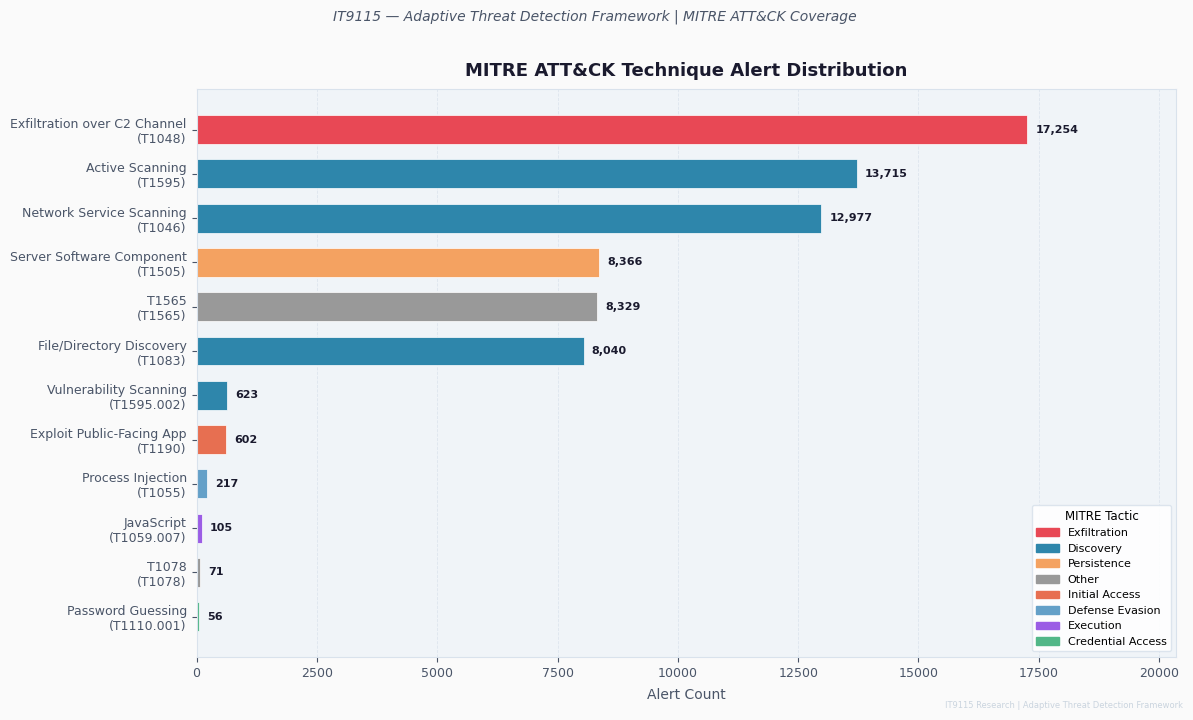

In [7]:
def fig1a_mitre_technique_bars():
    techniques = data.mitre_top
    if not techniques:
        print("No MITRE data"); return

    top     = techniques[:12]
    labels  = [TECH_NAMES.get(t["id"], t["id"]) for t in top]
    counts  = [t["count"] for t in top]
    tactics = [TACTIC_MAP.get(t["id"], "Other") for t in top]
    colors  = [TACTIC_COLOR.get(tac, "#999999") for tac in tactics]
    ids     = [t["id"] for t in top]

    fig, ax = plt.subplots(figsize=(12, 7), facecolor=PALETTE["bg"])
    y = range(len(labels))
    bars = ax.barh(y, counts, height=0.65, color=colors,
                   edgecolor="white", linewidth=0.5)

    max_c = max(counts) if counts else 1
    for bar, count, tid in zip(bars, counts, ids):
        ax.text(bar.get_width() + max_c * 0.01,
                bar.get_y() + bar.get_height() / 2,
                f"{count:,}", va="center", **FONT_ANNOT, fontweight="bold")

    ax.set_yticks(list(y))
    ax.set_yticklabels(
        [f"{lab}\n({tid})" for lab, tid in zip(labels, ids)],
        fontsize=9, color=PALETTE["text"])
    ax.invert_yaxis()
    ax.set_xlim(0, max_c * 1.18)
    _apply_style(ax,
                 title="MITRE ATT&CK Technique Alert Distribution",
                 xlabel="Alert Count", grid_axis="x")

    seen = {}
    patches = []
    for tac in tactics:
        if tac not in seen:
            seen[tac] = True
            patches.append(mpatches.Patch(color=TACTIC_COLOR.get(tac, "#999"), label=tac))
    ax.legend(handles=patches, loc="lower right", fontsize=8,
              framealpha=0.88, edgecolor=PALETTE["grid"],
              title="MITRE Tactic", title_fontsize=8.5)

    fig.suptitle(
        "IT9115 — Adaptive Threat Detection Framework | MITRE ATT&CK Coverage",
        **FONT_SUPTITLE, y=1.01)
    _watermark(fig)
    _save(fig, "fig1a_mitre_technique_bars")

fig1a_mitre_technique_bars()

## Figure 1b — MITRE Coverage Donut & Hypothesis Status
Coverage percentage donut with hypothesis pass/fail badges.

  Saved: fig1b_mitre_coverage_donut.png   [203 KB  @300 dpi]


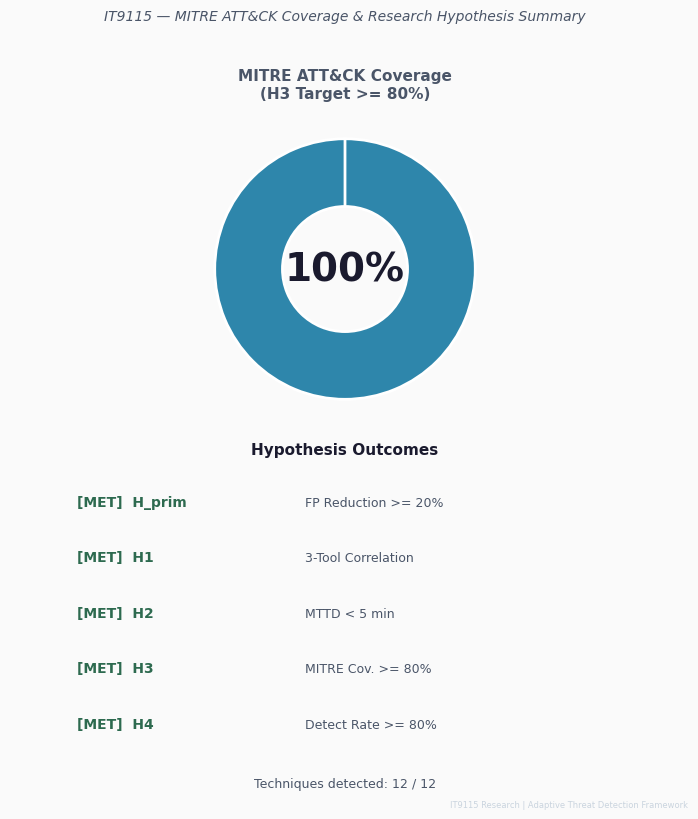

In [8]:
def fig1b_mitre_coverage_donut():
    cov_pct        = data.raw.get("mitre", {}).get("coverage_pct", 0)
    detected_count = data.raw.get("mitre", {}).get("techniques_in_scope_detected", 0)
    total_count    = data.raw.get("mitre", {}).get("total_targeted_techniques", 0)
    hy             = data.hypothesis

    fig, ax = plt.subplots(figsize=(7, 8), facecolor=PALETTE["bg"])
    ax.set_facecolor(PALETTE["panel"])
    ax.axis("off")

    donut_ax = ax.inset_axes([0.10, 0.50, 0.80, 0.44])
    missed_pct = 100 - cov_pct
    donut_ax.pie([cov_pct, missed_pct],
                 colors=[PALETTE["detected"], "#E0E8F0"],
                 startangle=90, counterclock=False,
                 wedgeprops=dict(width=0.52, edgecolor="white", linewidth=2.0))
    donut_ax.text(0, 0, f"{cov_pct:.0f}%", ha="center", va="center",
                  fontsize=28, fontweight="bold", color=PALETTE["text"])
    donut_ax.set_title("MITRE ATT&CK Coverage\n(H3 Target >= 80%)",
                       fontsize=11, fontweight="bold", color=PALETTE["subtext"], pad=6)

    hyp_labels = [
        ("H_prim", "FP Reduction >= 20%", hy.get("primary", {}).get("met", False)),
        ("H1",     "3-Tool Correlation",   hy.get("H1",      {}).get("met", False)),
        ("H2",     "MTTD < 5 min",         hy.get("H2",      {}).get("met", False)),
        ("H3",     "MITRE Cov. >= 80%",    hy.get("H3",      {}).get("met", False)),
        ("H4",     "Detect Rate >= 80%",   hy.get("H4",      {}).get("met", False)),
    ]
    ax.text(0.5, 0.47, "Hypothesis Outcomes", ha="center",
            fontsize=11, fontweight="bold", color=PALETTE["text"],
            transform=ax.transAxes)

    y_pos = 0.40
    for hid, hdesc, hmet in hyp_labels:
        icon = "MET" if hmet else "NOT MET"
        col  = PALETTE["green"] if hmet else PALETTE["missed"]
        ax.text(0.10, y_pos, f"[{icon}]  {hid}", ha="left", fontsize=10,
                color=col, fontweight="bold", transform=ax.transAxes)
        ax.text(0.44, y_pos, hdesc, ha="left", fontsize=9,
                color=PALETTE["subtext"], transform=ax.transAxes)
        y_pos -= 0.075

    ax.text(0.5, 0.02,
            f"Techniques detected: {detected_count} / {total_count}",
            ha="center", fontsize=9, color=PALETTE["subtext"],
            transform=ax.transAxes)

    fig.suptitle(
        "IT9115 — MITRE ATT&CK Coverage & Research Hypothesis Summary",
        **FONT_SUPTITLE, y=1.01)
    _watermark(fig)
    _save(fig, "fig1b_mitre_coverage_donut")

fig1b_mitre_coverage_donut()

---
## Figure 2a — Alert Classification Confusion Matrix
TP / FP / FN / TN visual grid with counts.

  Saved: fig2a_confusion_matrix.png   [232 KB  @300 dpi]


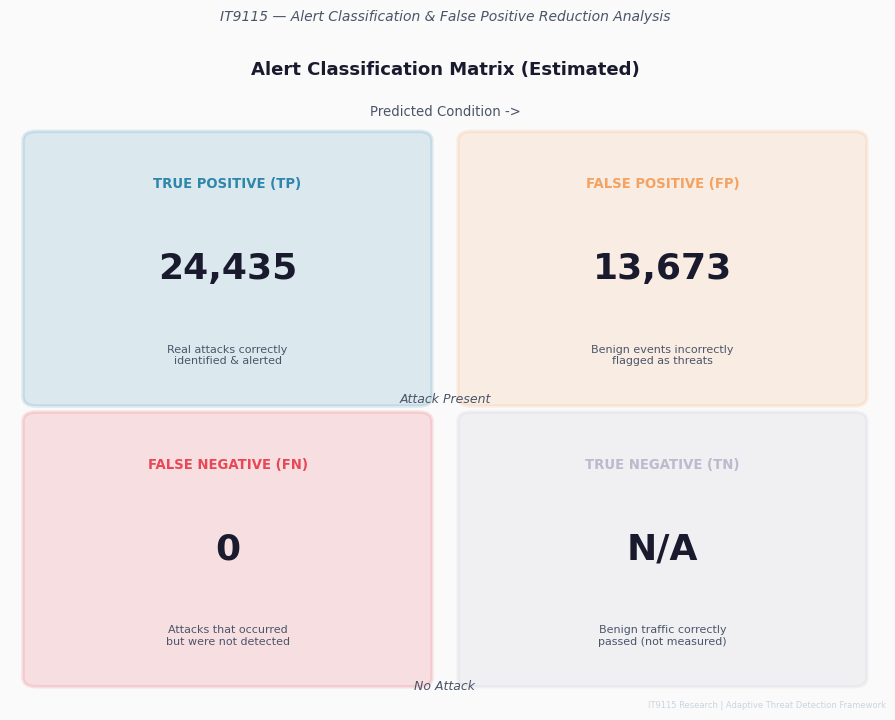

In [9]:
def fig2a_confusion_matrix():
    fp_data  = data.fp
    raw      = fp_data.get("raw_alerts", 14386)
    fp_est   = fp_data.get("fp_count_used", 0)
    dup      = fp_data.get("duplicate_alerts", 0)
    tp_count = raw - fp_est - dup
    fp_count = fp_est
    fn_count = sum(1 for s in data.detection_scenarios if s.get("status") != "DETECTED")

    cells_data = [
        (0, 0, "TRUE POSITIVE (TP)",  tp_count, "#2E86AB", "Real attacks correctly\nidentified & alerted"),
        (0, 1, "FALSE POSITIVE (FP)", fp_count, "#F4A261", "Benign events incorrectly\nflagged as threats"),
        (1, 0, "FALSE NEGATIVE (FN)", fn_count, "#E84855", "Attacks that occurred\nbut were not detected"),
        (1, 1, "TRUE NEGATIVE (TN)",  "N/A",    "#BBBBCC", "Benign traffic correctly\npassed (not measured)"),
    ]
    offsets  = [(0.03, 0.50), (0.53, 0.50), (0.03, 0.04), (0.53, 0.04)]
    cell_w, cell_h = 0.44, 0.42

    fig, ax = plt.subplots(figsize=(9, 7), facecolor=PALETTE["bg"])
    ax.set_facecolor(PALETTE["panel"])
    ax.axis("off")
    ax.set_title("Alert Classification Matrix (Estimated)", **FONT_TITLE, pad=12)

    for (r, c, lbl, val, col, expl), (ox, oy) in zip(cells_data, offsets):
        rect = FancyBboxPatch((ox, oy), cell_w, cell_h,
                              boxstyle="round,pad=0.015",
                              facecolor=col, alpha=0.15,
                              edgecolor=col, linewidth=2.5,
                              transform=ax.transAxes)
        ax.add_patch(rect)
        ax.text(ox + cell_w/2, oy + cell_h - 0.06, lbl,
                ha="center", va="top", fontsize=9.5, fontweight="bold",
                color=col, transform=ax.transAxes)
        val_str = f"{val:,}" if isinstance(val, int) else str(val)
        ax.text(ox + cell_w/2, oy + cell_h/2, val_str,
                ha="center", va="center", fontsize=26, fontweight="bold",
                color=PALETTE["text"], transform=ax.transAxes)
        ax.text(ox + cell_w/2, oy + 0.05, expl,
                ha="center", va="bottom", fontsize=8,
                color=PALETTE["subtext"], transform=ax.transAxes,
                multialignment="center")

    ax.text(0.5, 0.96, "Predicted Condition ->", ha="center", fontsize=9.5,
            color=PALETTE["subtext"], transform=ax.transAxes)
    ax.text(0.50, 0.49, "Attack Present", ha="center", fontsize=9,
            color=PALETTE["subtext"], transform=ax.transAxes, fontstyle="italic")
    ax.text(0.50, 0.02, "No Attack", ha="center", fontsize=9,
            color=PALETTE["subtext"], transform=ax.transAxes, fontstyle="italic")

    fig.suptitle(
        "IT9115 — Alert Classification & False Positive Reduction Analysis",
        **FONT_SUPTITLE, y=1.01)
    _watermark(fig)
    _save(fig, "fig2a_confusion_matrix")

fig2a_confusion_matrix()

## Figure 2b — Precision, Recall & Alert Volume Reduction
Metric summary cards: precision/recall and FP volume reduction.

  Saved: fig2b_precision_recall_cards.png   [148 KB  @300 dpi]


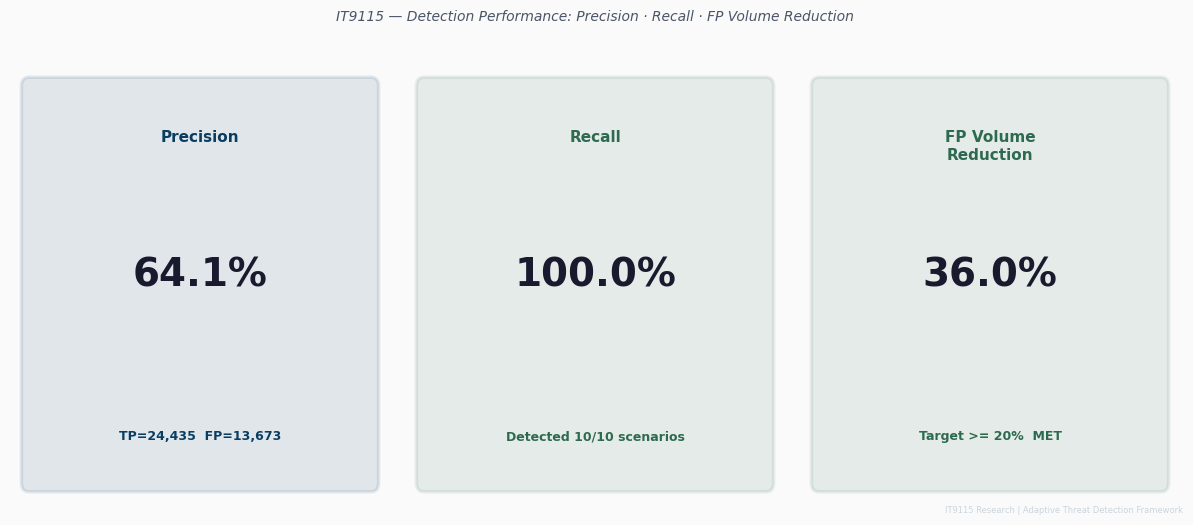

In [10]:
def fig2b_precision_recall_cards():
    fp_data  = data.fp
    raw      = fp_data.get("raw_alerts", 14386)
    fp_est   = fp_data.get("fp_count_used", 0)
    dup      = fp_data.get("duplicate_alerts", 0)
    tp_count = raw - fp_est - dup
    fp_count = fp_est
    vol_red  = fp_data.get("total_volume_reduction_pct", 0)

    total_sc    = len(data.detection_scenarios)
    detected_sc = sum(1 for s in data.detection_scenarios if s.get("status") == "DETECTED")
    recall      = detected_sc / total_sc * 100 if total_sc else 0
    precision   = tp_count / (tp_count + fp_count) * 100 if (tp_count + fp_count) else 0

    cards = [
        ("Precision",    f"{precision:.1f}%",
         f"TP={tp_count:,}  FP={fp_count:,}", PALETTE["accent"]),
        ("Recall",       f"{recall:.1f}%",
         f"Detected {detected_sc}/{total_sc} scenarios", PALETTE["green"]),
        ("FP Volume\nReduction", f"{vol_red:.1f}%",
         "Target >= 20%  " + ("MET" if vol_red >= 20 else "NOT MET"),
         PALETTE["green"] if vol_red >= 20 else PALETTE["warning"]),
    ]

    fig, axes = plt.subplots(1, 3, figsize=(12, 5), facecolor=PALETTE["bg"])
    fig.subplots_adjust(wspace=0.32)

    for ax, (title, big_val, sub, col) in zip(axes, cards):
        ax.set_facecolor(PALETTE["panel"])
        ax.axis("off")
        ax.add_patch(FancyBboxPatch(
            (0.05, 0.05), 0.90, 0.90, boxstyle="round,pad=0.02",
            facecolor=col, alpha=0.10, edgecolor=col, linewidth=2.5,
            transform=ax.transAxes))
        ax.text(0.5, 0.85, title, ha="center", va="top",
                fontsize=11, fontweight="bold", color=col,
                transform=ax.transAxes, multialignment="center")
        ax.text(0.5, 0.52, big_val, ha="center", va="center",
                fontsize=28, fontweight="bold", color=PALETTE["text"],
                transform=ax.transAxes)
        ax.text(0.5, 0.14, sub, ha="center", va="bottom",
                fontsize=9, color=col, fontweight="bold",
                transform=ax.transAxes, multialignment="center")

    fig.suptitle(
        "IT9115 — Detection Performance: Precision · Recall · FP Volume Reduction",
        **FONT_SUPTITLE, y=1.02)
    _watermark(fig)
    _save(fig, "fig2b_precision_recall_cards")

fig2b_precision_recall_cards()

---
## Figure 3a — Scenario Detection Coverage (Alert Volume)
Horizontal bars per attack scenario, colour-coded by detection status.

  Saved: fig3a_attack_coverage_bars.png   [312 KB  @300 dpi]


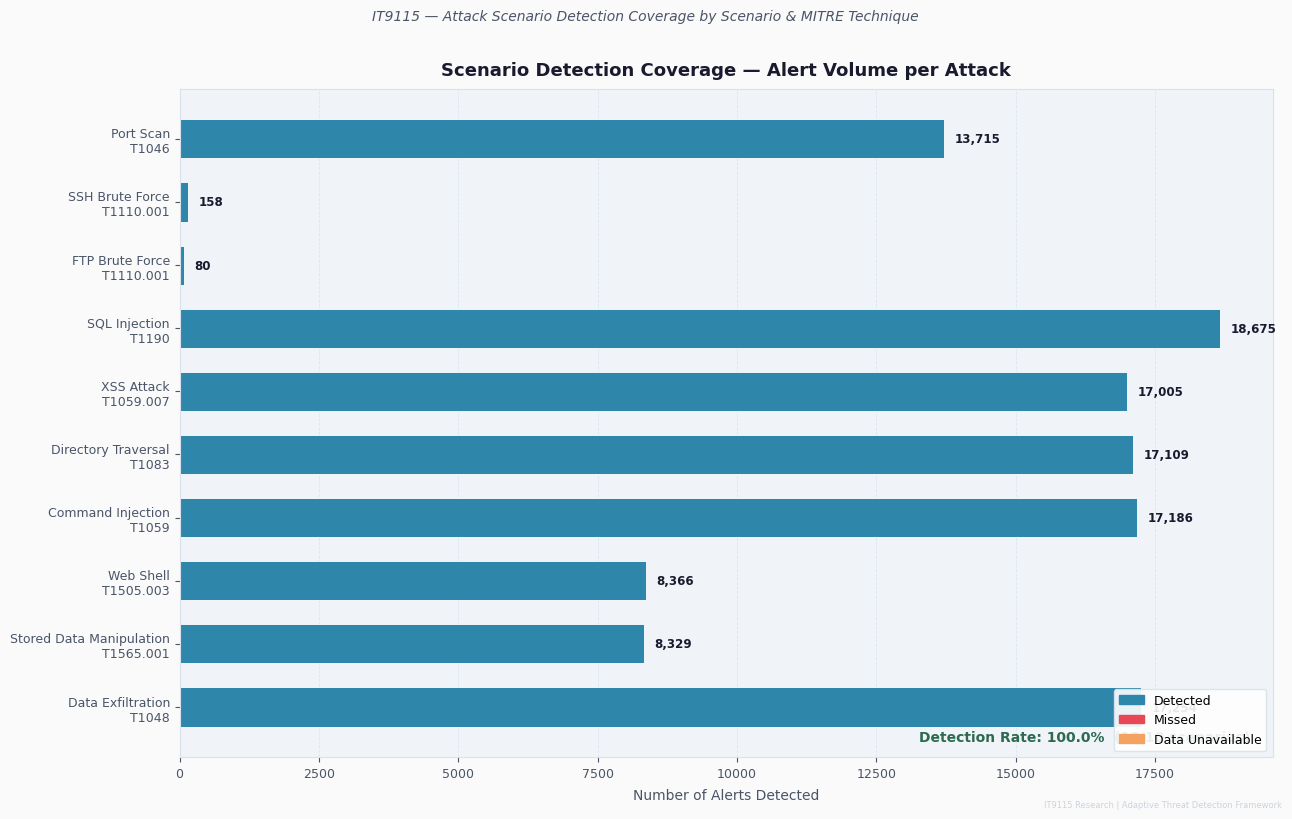

In [11]:
def fig3a_attack_coverage_bars():
    scenarios = data.detection_scenarios
    if not scenarios:
        print("No scenario data"); return

    names    = [s["name"] for s in scenarios]
    statuses = [s.get("status", "MISSED") for s in scenarios]
    counts   = [s.get("count", 0) for s in scenarios]
    mitre    = [s.get("mitre", "") for s in scenarios]
    color_map = {"DETECTED": PALETTE["detected"], "MISSED": PALETTE["missed"],
                 "DATA_UNAVAILABLE": PALETTE["warning"]}
    bar_colors = [color_map.get(st, PALETTE["warning"]) for st in statuses]

    fig, ax = plt.subplots(figsize=(13, 8), facecolor=PALETTE["bg"])
    y    = range(len(names))
    bars = ax.barh(y, counts, height=0.62, color=bar_colors,
                   edgecolor="white", linewidth=0.6)
    ax.set_yticks(list(y))
    ax.set_yticklabels(
        [f"{n}\n{m}" for n, m in zip(names, mitre)],
        fontsize=9, color=PALETTE["text"])
    ax.invert_yaxis()

    max_c = max(counts) if counts else 1
    for bar, cnt, st in zip(bars, counts, statuses):
        if cnt > 0:
            ax.text(cnt + max_c * 0.01, bar.get_y() + bar.get_height() / 2,
                    f"{cnt:,}", va="center", fontsize=8.5, fontweight="bold",
                    color=PALETTE["text"])
        elif st == "MISSED":
            ax.text(max_c * 0.01, bar.get_y() + bar.get_height() / 2,
                    "  NO ALERTS", va="center", fontsize=8.5,
                    color=PALETTE["missed"], fontweight="bold")

    _apply_style(ax, title="Scenario Detection Coverage — Alert Volume per Attack",
                 xlabel="Number of Alerts Detected", grid_axis="x")
    legend_items = [
        mpatches.Patch(color=PALETTE["detected"], label="Detected"),
        mpatches.Patch(color=PALETTE["missed"],   label="Missed"),
        mpatches.Patch(color=PALETTE["warning"],  label="Data Unavailable"),
    ]
    ax.legend(handles=legend_items, loc="lower right", fontsize=9,
              framealpha=0.9, edgecolor=PALETTE["grid"])

    det_rate  = data.raw.get("detection", {}).get("detection_rate_pct", 0)
    det_count = sum(1 for s in scenarios if s.get("status") == "DETECTED")
    badge_col = PALETTE["green"] if det_rate >= 80 else PALETTE["warning"]
    ax.text(0.98, 0.02,
            f"Detection Rate: {det_rate:.1f}%  ({det_count}/{len(scenarios)} scenarios)",
            ha="right", va="bottom", fontsize=10, fontweight="bold",
            color=badge_col, transform=ax.transAxes)

    fig.suptitle(
        "IT9115 — Attack Scenario Detection Coverage by Scenario & MITRE Technique",
        **FONT_SUPTITLE, y=1.01)
    _watermark(fig)
    _save(fig, "fig3a_attack_coverage_bars")

fig3a_attack_coverage_bars()

## Figure 3b — Scenario Summary Table
Tabular view of all scenarios with OSI layer, detection status, and MITRE tactic.

  Saved: fig3b_attack_coverage_table.png   [273 KB  @300 dpi]


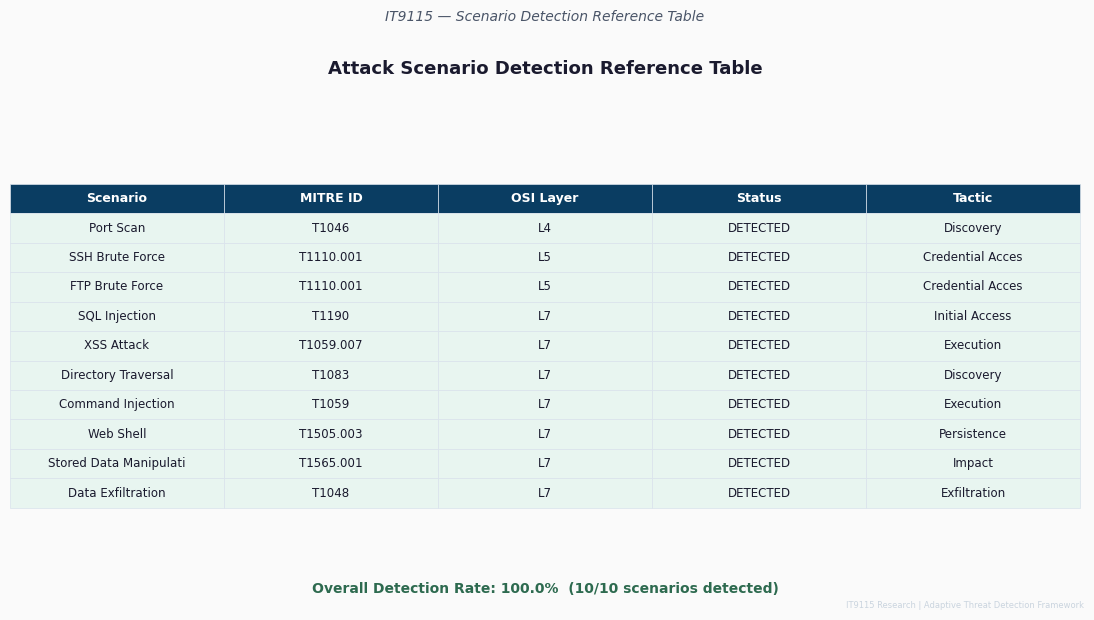

In [12]:
def fig3b_attack_coverage_table():
    scenarios = data.detection_scenarios
    if not scenarios:
        print("No scenario data"); return

    names    = [s["name"] for s in scenarios]
    statuses = [s.get("status", "MISSED") for s in scenarios]
    mitre    = [s.get("mitre", "") for s in scenarios]
    osi      = [s.get("osi_layer", 7) for s in scenarios]
    tactics  = [s.get("tactic", "") for s in scenarios]

    n = len(names)
    fig, ax = plt.subplots(figsize=(11, max(6, n * 0.42 + 1.5)),
                            facecolor=PALETTE["bg"])
    ax.axis("off")
    ax.set_facecolor(PALETTE["panel"])
    ax.set_title("Attack Scenario Detection Reference Table", **FONT_TITLE, pad=12)

    col_labels = ["Scenario", "MITRE ID", "OSI Layer", "Status", "Tactic"]
    table_data = [
        [name[:22], mid, f"L{o}", st[:12], tac[:16]]
        for name, mid, o, st, tac in zip(names, mitre, osi, statuses, tactics)
    ]

    tbl = ax.table(cellText=table_data, colLabels=col_labels,
                   loc="center", cellLoc="center")
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(8.5)
    tbl.scale(1.0, 1.6)

    for (row, col), cell in tbl.get_celld().items():
        cell.set_edgecolor(PALETTE["grid"])
        cell.set_linewidth(0.5)
        if row == 0:
            cell.set_facecolor(PALETTE["accent"])
            cell.set_text_props(color="white", fontweight="bold", fontsize=9)
        else:
            st_val = table_data[row - 1][3]
            if "DETECTED" in st_val:  cell.set_facecolor("#E8F5F0")
            elif "MISSED"  in st_val: cell.set_facecolor("#FCE8E8")
            else:                     cell.set_facecolor(PALETTE["panel"])
            cell.set_text_props(color=PALETTE["text"])

    det_rate  = data.raw.get("detection", {}).get("detection_rate_pct", 0)
    det_count = sum(1 for s in scenarios if s.get("status") == "DETECTED")
    badge_col = PALETTE["green"] if det_rate >= 80 else PALETTE["warning"]
    ax.text(0.5, 0.01,
            f"Overall Detection Rate: {det_rate:.1f}%  "
            f"({det_count}/{len(scenarios)} scenarios detected)",
            ha="center", va="bottom", fontsize=10, fontweight="bold",
            color=badge_col, transform=ax.transAxes)

    fig.suptitle("IT9115 — Scenario Detection Reference Table",
                 **FONT_SUPTITLE, y=1.01)
    _watermark(fig)
    _save(fig, "fig3b_attack_coverage_table")

fig3b_attack_coverage_table()

---
## Figure 4a — Mean Time to Detect (MTTD) per Attack Scenario
Lollipop chart with target and mean reference lines.

  Saved: fig4a_mttd_lollipop.png   [650 KB  @300 dpi]


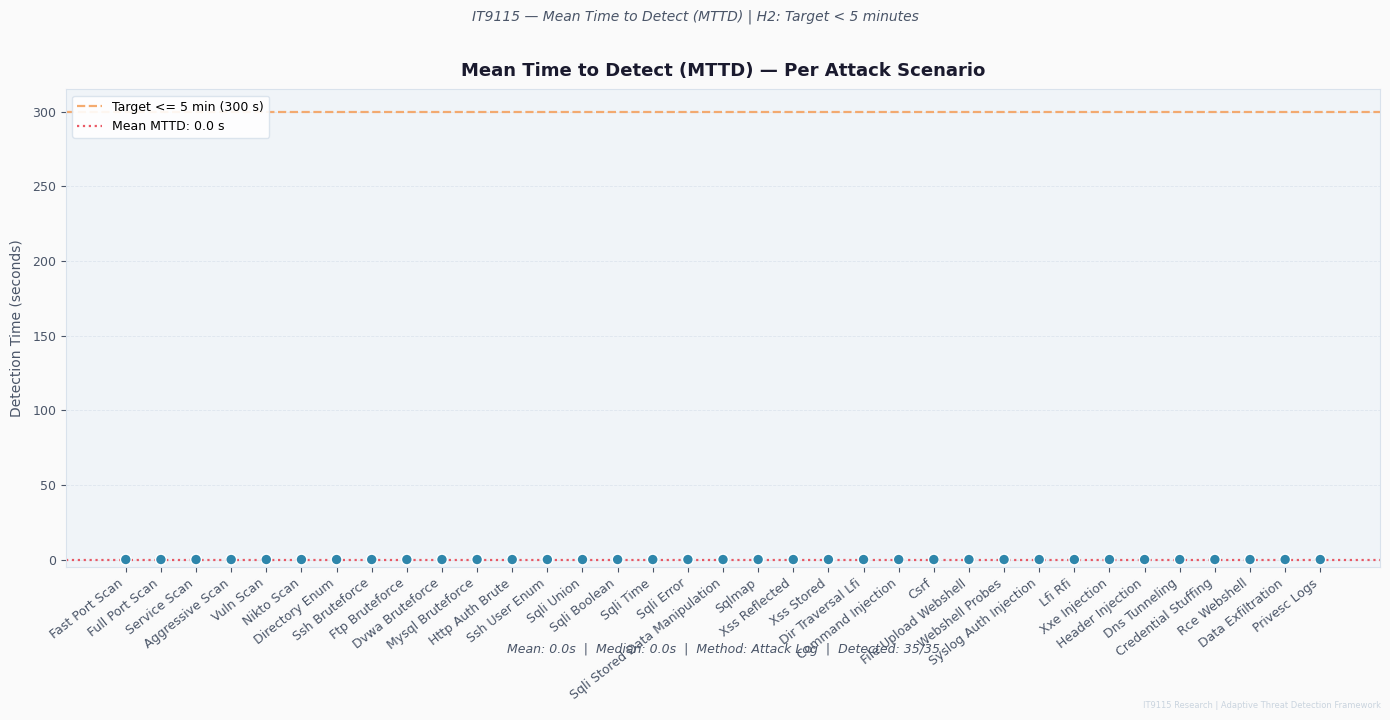

In [13]:
def fig4a_mttd_lollipop():
    rows = data.mttd_rows
    if not rows:
        per_attack = data.mttd.get("per_attack", [])
        rows = [{"attack": a["attack"], "mttd_seconds": str(a.get("mttd_seconds", 0)),
                 "status": a.get("status", ""), "mitre": a.get("mitre", "")}
                for a in per_attack]
    if not rows:
        print("No MTTD data"); return

    detected   = [r for r in rows if r.get("status") == "detected"]
    names      = [r["attack"].replace("_", " ").title() for r in detected]
    mttd_s     = [float(r.get("mttd_seconds", 0)) for r in detected]
    mean_val   = data.mttd.get("mean_mttd_seconds", 0) or (sum(mttd_s)/len(mttd_s) if mttd_s else 0)
    median_val = data.mttd.get("median_mttd_seconds", 0) or 0
    target_s   = 300

    fig, ax = plt.subplots(figsize=(14, 7), facecolor=PALETTE["bg"])
    x = range(len(names))
    bar_colors = [PALETTE["detected"] if v <= target_s else PALETTE["warning"] for v in mttd_s]

    ax.vlines(x, 0, mttd_s, color=bar_colors, linewidth=2.2, alpha=0.85)
    ax.scatter(x, mttd_s, color=bar_colors, s=60, zorder=5,
               edgecolors="white", linewidths=1.0)
    ax.axhline(target_s, color=PALETTE["warning"], linewidth=1.6, linestyle="--",
               alpha=0.9, label=f"Target <= 5 min ({target_s} s)")
    ax.axhline(mean_val, color=PALETTE["missed"],  linewidth=1.6, linestyle=":",
               alpha=0.9, label=f"Mean MTTD: {mean_val:.1f} s")

    for xi, (v, nm) in enumerate(zip(mttd_s, names)):
        if v > 60:
            ax.text(xi, v + 5, f"{v:.0f}s", ha="center", fontsize=7.5,
                    color=PALETTE["text"], fontweight="bold")

    ax.set_xticks(list(x))
    ax.set_xticklabels(names, rotation=38, ha="right", fontsize=8.5,
                       color=PALETTE["text"])
    ax.set_ylim(bottom=-5)
    _apply_style(ax, title="Mean Time to Detect (MTTD) — Per Attack Scenario",
                 ylabel="Detection Time (seconds)", grid_axis="y")
    ax.legend(fontsize=9, framealpha=0.9, edgecolor=PALETTE["grid"], loc="upper left")

    method_str = data.mttd.get("method", "attack_log").replace("_", " ").title()
    ax.text(0.5, -0.18,
            f"Mean: {mean_val:.1f}s  |  Median: {median_val:.1f}s  |  "
            f"Method: {method_str}  |  Detected: {len(detected)}/{len(rows)}",
            ha="center", transform=ax.transAxes, fontsize=9,
            color=PALETTE["subtext"], fontstyle="italic")

    fig.suptitle("IT9115 — Mean Time to Detect (MTTD) | H2: Target < 5 minutes",
                 **FONT_SUPTITLE, y=1.01)
    _watermark(fig)
    _save(fig, "fig4a_mttd_lollipop")

fig4a_mttd_lollipop()

## Figure 4b — MTTD Distribution Histogram
Frequency of attack detection times across discrete time buckets.

  Saved: fig4b_mttd_histogram.png   [167 KB  @300 dpi]


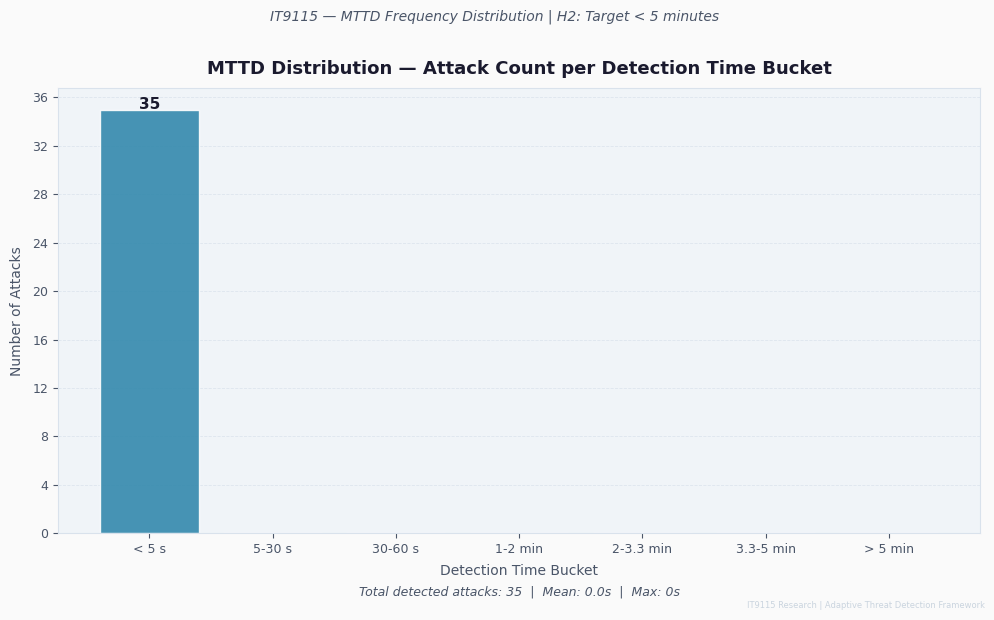

In [14]:
def fig4b_mttd_histogram():
    rows = data.mttd_rows
    if not rows:
        per_attack = data.mttd.get("per_attack", [])
        rows = [{"attack": a["attack"], "mttd_seconds": str(a.get("mttd_seconds", 0)),
                 "status": a.get("status", "")} for a in per_attack]

    detected = [r for r in rows if r.get("status") == "detected"]
    mttd_s   = [float(r.get("mttd_seconds", 0)) for r in detected]
    if len(mttd_s) < 2:
        print("Insufficient data for histogram"); return

    bins       = [0, 5, 30, 60, 120, 200, 300, max(mttd_s) + 10]
    bin_labels = ["< 5 s", "5-30 s", "30-60 s", "1-2 min", "2-3.3 min", "3.3-5 min", "> 5 min"]
    hist_counts = [0] * (len(bins) - 1)
    for v in mttd_s:
        for i in range(len(bins) - 1):
            if bins[i] <= v < bins[i + 1]:
                hist_counts[i] += 1; break

    fig, ax = plt.subplots(figsize=(10, 6), facecolor=PALETTE["bg"])
    bx   = range(len(hist_counts))
    ax.bar(bx, hist_counts, color=PALETTE["detected"],
           edgecolor="white", linewidth=1.0, alpha=0.88)
    ax.set_xticks(list(bx))
    ax.set_xticklabels(bin_labels, fontsize=9.5)
    ax.yaxis.set_major_locator(MaxNLocator(integer=True))
    _apply_style(ax, title="MTTD Distribution — Attack Count per Detection Time Bucket",
                 xlabel="Detection Time Bucket", ylabel="Number of Attacks", grid_axis="y")
    for xi, cnt in enumerate(hist_counts):
        if cnt > 0:
            ax.text(xi, cnt + 0.05, str(cnt), ha="center",
                    fontsize=11, fontweight="bold", color=PALETTE["text"])

    mean_v = sum(mttd_s) / len(mttd_s)
    ax.text(0.5, -0.14,
            f"Total detected attacks: {len(detected)}  |  "
            f"Mean: {mean_v:.1f}s  |  Max: {max(mttd_s):.0f}s",
            ha="center", transform=ax.transAxes, fontsize=9,
            color=PALETTE["subtext"], fontstyle="italic")

    fig.suptitle("IT9115 — MTTD Frequency Distribution | H2: Target < 5 minutes",
                 **FONT_SUPTITLE, y=1.01)
    _watermark(fig)
    _save(fig, "fig4b_mttd_histogram")

fig4b_mttd_histogram()

---
## Figure 5a — SOAR Block Actions by Tier
Realtime, Test, and Production SOAR active-response block counts.

  Saved: fig5a_mttc_soar_bars.png   [150 KB  @300 dpi]


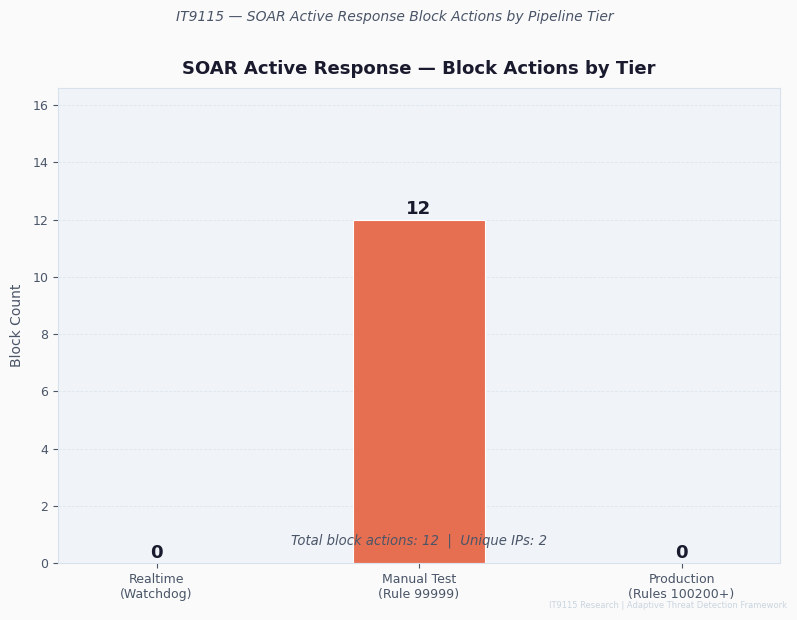

In [15]:
def fig5a_mttc_soar_bars():
    soar    = data.raw.get("soar", {})
    t_rt    = soar.get("watchdog_blocks",   0)
    t_test  = soar.get("test_blocks",       0)
    t_prod  = soar.get("production_blocks", 0)
    t_total = soar.get("block_actions",     0)

    tiers    = ["Realtime\n(Watchdog)", "Manual Test\n(Rule 99999)", "Production\n(Rules 100200+)"]
    values   = [t_rt, t_test, t_prod]
    t_colors = [PALETTE["zeek"], PALETTE["suricata"], PALETTE["wazuh"]]

    fig, ax = plt.subplots(figsize=(8, 6), facecolor=PALETTE["bg"])
    bars = ax.bar(tiers, values, color=t_colors,
                  edgecolor="white", linewidth=0.8, width=0.5)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.2,
                str(val), ha="center", fontsize=13, fontweight="bold",
                color=PALETTE["text"])
    ax.set_ylim(0, max(values) * 1.30 + 1)
    _apply_style(ax, title="SOAR Active Response — Block Actions by Tier",
                 ylabel="Block Count", grid_axis="y")
    ax.text(0.5, 0.04,
            f"Total block actions: {t_total}  |  Unique IPs: {soar.get('unique_ips', 0)}",
            ha="center", transform=ax.transAxes, fontsize=9.5,
            color=PALETTE["subtext"], fontstyle="italic")

    fig.suptitle("IT9115 — SOAR Active Response Block Actions by Pipeline Tier",
                 **FONT_SUPTITLE, y=1.01)
    _watermark(fig)
    _save(fig, "fig5a_mttc_soar_bars")

fig5a_mttc_soar_bars()

## Figure 5b — Mean Time to Contain (MTTC) Gauge
Semi-circular gauge showing MTTC vs. the 5-second containment target.

  Saved: fig5b_mttc_gauge.png   [160 KB  @300 dpi]


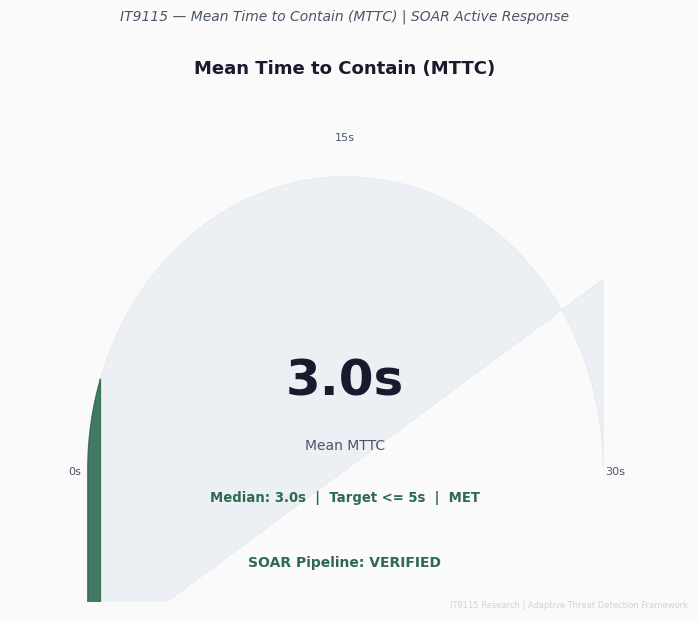

In [16]:
def fig5b_mttc_gauge():
    mttc   = data.mttc
    mean_v = mttc.get("mean_mttc_seconds",   3.0) or 3.0
    med_v  = mttc.get("median_mttc_seconds", 3.0) or 3.0
    target = 5.0
    soar   = data.raw.get("soar", {})

    fig, ax = plt.subplots(figsize=(7, 6), facecolor=PALETTE["bg"])
    ax.set_facecolor(PALETTE["panel"])
    _apply_style(ax, title="Mean Time to Contain (MTTC)", grid_axis=None)

    theta = np.linspace(np.pi, 0, 300)
    r_outer, r_inner = 1.0, 0.65

    ax.fill_between(
        np.cos(theta)*r_outer, np.sin(theta)*r_outer,
        np.cos(theta)*r_inner, np.sin(theta)*r_inner,
        color=PALETTE["grid"], alpha=0.4)

    display_max = 30.0
    fill_ratio  = min(mean_v / display_max, 1.0)
    theta_fill  = np.linspace(np.pi, np.pi - fill_ratio * np.pi, 200)
    fill_color  = PALETTE["green"] if mean_v <= target else PALETTE["warning"]
    ax.fill_between(
        np.cos(theta_fill)*r_outer, np.sin(theta_fill)*r_outer,
        np.cos(theta_fill)*r_inner, np.sin(theta_fill)*r_inner,
        color=fill_color, alpha=0.88)

    ax.text(0, 0.30, f"{mean_v:.1f}s", ha="center", va="center",
            fontsize=36, fontweight="bold", color=PALETTE["text"])
    ax.text(0, 0.08, "Mean MTTC", ha="center", va="center",
            fontsize=10, color=PALETTE["subtext"])
    outcome = "MET" if mean_v <= target else "NOT MET"
    ax.text(0, -0.10, f"Median: {med_v:.1f}s  |  Target <= 5s  |  {outcome}",
            ha="center", va="center", fontsize=9.5, color=fill_color, fontweight="bold")

    ax.text(-1.05, -0.02, "0s",  ha="center", fontsize=8, color=PALETTE["subtext"])
    ax.text(0,      1.12, "15s", ha="center", fontsize=8, color=PALETTE["subtext"])
    ax.text(1.05,  -0.02, "30s", ha="center", fontsize=8, color=PALETTE["subtext"])

    pipe_status = soar.get("pipeline_status", "UNVERIFIED")
    ax.text(0, -0.32, f"SOAR Pipeline: {pipe_status}",
            ha="center", va="center", fontsize=10, fontweight="bold",
            color=PALETTE["green"] if "VERIFIED" in pipe_status else PALETTE["warning"])

    ax.set_xlim(-1.3, 1.3)
    ax.set_ylim(-0.45, 1.3)
    ax.axis("off")

    fig.suptitle("IT9115 — Mean Time to Contain (MTTC) | SOAR Active Response",
                 **FONT_SUPTITLE, y=1.01)
    _watermark(fig)
    _save(fig, "fig5b_mttc_gauge")

fig5b_mttc_gauge()

## Figure 5c — SOAR Pipeline Summary Panel
Tabular panel summarising SOAR response counts, rule triggers, and actioned IPs.

  Saved: fig5c_mttc_pipeline.png   [141 KB  @300 dpi]


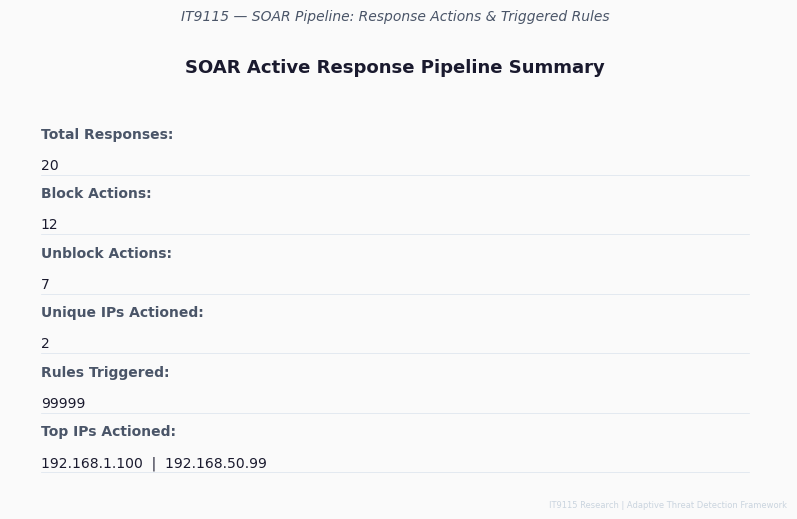

In [17]:
def fig5c_mttc_pipeline():
    soar            = data.raw.get("soar", {})
    rules_triggered = soar.get("rule_ids_triggered", {})
    ips_actioned    = soar.get("ips_actioned", [])

    info_lines = [
        ("Total Responses",     str(soar.get("total_responses",  0))),
        ("Block Actions",       str(soar.get("block_actions",    0))),
        ("Unblock Actions",     str(soar.get("unblock_actions",  0))),
        ("Unique IPs Actioned", str(soar.get("unique_ips",       0))),
        ("Rules Triggered",     ", ".join(rules_triggered.keys()) or "None"),
        ("Top IPs Actioned",    "  |  ".join(ips_actioned[:4])  if ips_actioned else "None"),
    ]

    fig, ax = plt.subplots(figsize=(8, 5), facecolor=PALETTE["bg"])
    ax.set_facecolor(PALETTE["panel"])
    ax.axis("off")
    ax.set_title("SOAR Active Response Pipeline Summary", **FONT_TITLE, pad=12)

    y = 0.88
    for label, value in info_lines:
        ax.text(0.04, y, f"{label}:", ha="left", fontsize=10, fontweight="bold",
                color=PALETTE["subtext"], transform=ax.transAxes)
        ax.text(0.04, y - 0.075, value, ha="left", fontsize=10,
                color=PALETTE["text"], transform=ax.transAxes)
        ax.plot([0.04, 0.96], [y - 0.09, y - 0.09],
                color=PALETTE["grid"], linewidth=0.5,
                transform=ax.transAxes)
        y -= 0.145

    fig.suptitle("IT9115 — SOAR Pipeline: Response Actions & Triggered Rules",
                 **FONT_SUPTITLE, y=1.01)
    _watermark(fig)
    _save(fig, "fig5c_mttc_pipeline")

fig5c_mttc_pipeline()

---
## Figure 6a — Alert Severity Distribution (Donut)
Donut chart of severity levels with percentage annotations.

  Saved: fig6a_severity_donut.png   [176 KB  @300 dpi]


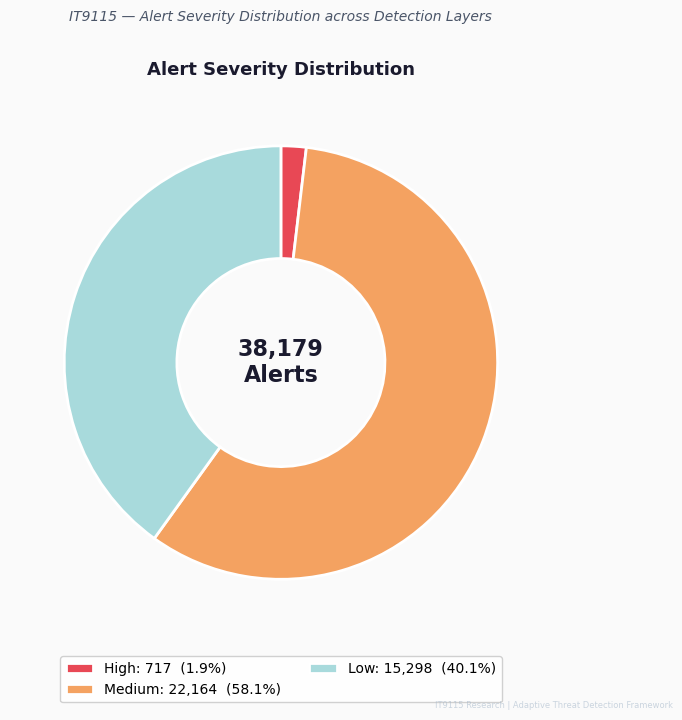

In [18]:
def fig6a_severity_donut():
    sev = data.severity
    if not sev:
        print("No severity data"); return

    sev_labels = ["Critical", "High", "Medium", "Low"]
    sev_values = [sev.get("critical",0), sev.get("high",0),
                  sev.get("medium",0),   sev.get("low",0)]
    sev_colors = [PALETTE["critical"], PALETTE["high"], PALETTE["medium"], PALETTE["low"]]
    total      = sev.get("total", sum(sev_values)) or 1

    non_zero = [(l, v, c) for l, v, c in zip(sev_labels, sev_values, sev_colors) if v > 0]
    if not non_zero:
        print("All severity values zero"); return
    labels_, values_, colors_ = zip(*non_zero)

    fig, ax = plt.subplots(figsize=(8, 7), facecolor=PALETTE["bg"])
    ax.set_facecolor(PALETTE["panel"])
    wedges, _ = ax.pie(values_, colors=colors_, startangle=90, counterclock=False,
                       wedgeprops=dict(width=0.52, edgecolor="white", linewidth=2.0))
    ax.text(0, 0, f"{total:,}\nAlerts", ha="center", va="center",
            fontsize=16, fontweight="bold", color=PALETTE["text"])
    legend_labels = [f"{l}: {v:,}  ({v/total*100:.1f}%)" for l, v in zip(labels_, values_)]
    ax.legend(wedges, legend_labels, loc="lower center",
              bbox_to_anchor=(0.5, -0.14), fontsize=10, framealpha=0.9, ncol=2)
    ax.set_title("Alert Severity Distribution", **FONT_TITLE, pad=12)

    fig.suptitle("IT9115 — Alert Severity Distribution across Detection Layers",
                 **FONT_SUPTITLE, y=1.01)
    _watermark(fig)
    _save(fig, "fig6a_severity_donut")

fig6a_severity_donut()

## Figure 6b — Alert Severity Count & Percentage Bars
Horizontal bars of alert counts per severity with percentage labels.

  Saved: fig6b_severity_bars.png   [128 KB  @300 dpi]


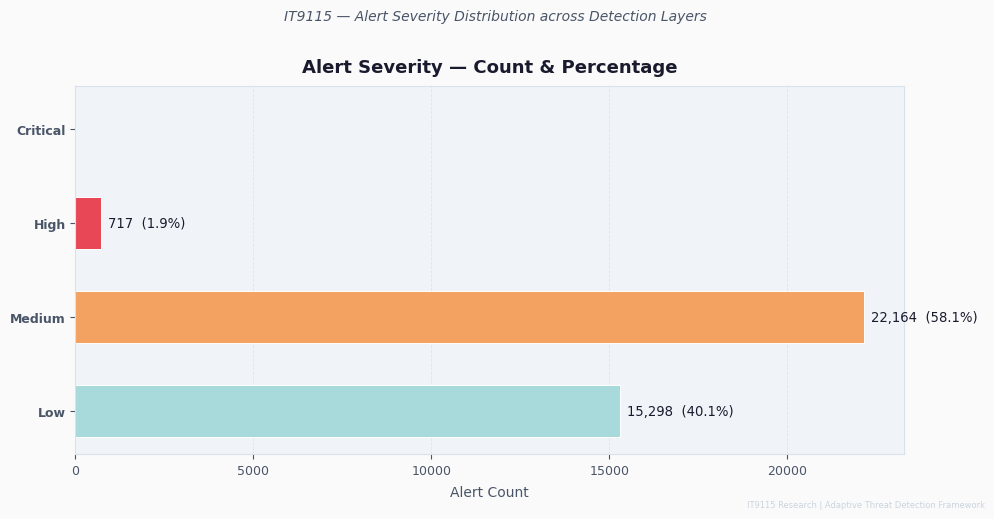

In [19]:
def fig6b_severity_bars():
    sev = data.severity
    if not sev:
        print("No severity data"); return

    sev_labels = ["Critical", "High", "Medium", "Low"]
    sev_values = [sev.get("critical",0), sev.get("high",0),
                  sev.get("medium",0),   sev.get("low",0)]
    sev_colors = [PALETTE["critical"], PALETTE["high"], PALETTE["medium"], PALETTE["low"]]
    total      = sev.get("total", sum(sev_values)) or 1

    fig, ax = plt.subplots(figsize=(10, 5), facecolor=PALETTE["bg"])
    y_pos = range(len(sev_labels))
    bars  = ax.barh(y_pos, sev_values, height=0.55,
                    color=sev_colors, edgecolor="white", linewidth=0.7)
    ax.set_yticks(list(y_pos))
    ax.set_yticklabels(sev_labels, fontsize=11, fontweight="bold")
    ax.invert_yaxis()
    for bar, val in zip(bars, sev_values):
        if val > 0:
            pct = val / total * 100
            ax.text(val + total * 0.005, bar.get_y() + bar.get_height() / 2,
                    f"{val:,}  ({pct:.1f}%)", va="center", fontsize=9.5, color=PALETTE["text"])
    _apply_style(ax, title="Alert Severity — Count & Percentage",
                 xlabel="Alert Count", grid_axis="x")

    fig.suptitle("IT9115 — Alert Severity Distribution across Detection Layers",
                 **FONT_SUPTITLE, y=1.01)
    _watermark(fig)
    _save(fig, "fig6b_severity_bars")

fig6b_severity_bars()

## Figure 6c — Alerts by Rule Category
Bar chart of alert counts grouped by detection rule category.

  Saved: fig6c_severity_rule_categories.png   [162 KB  @300 dpi]


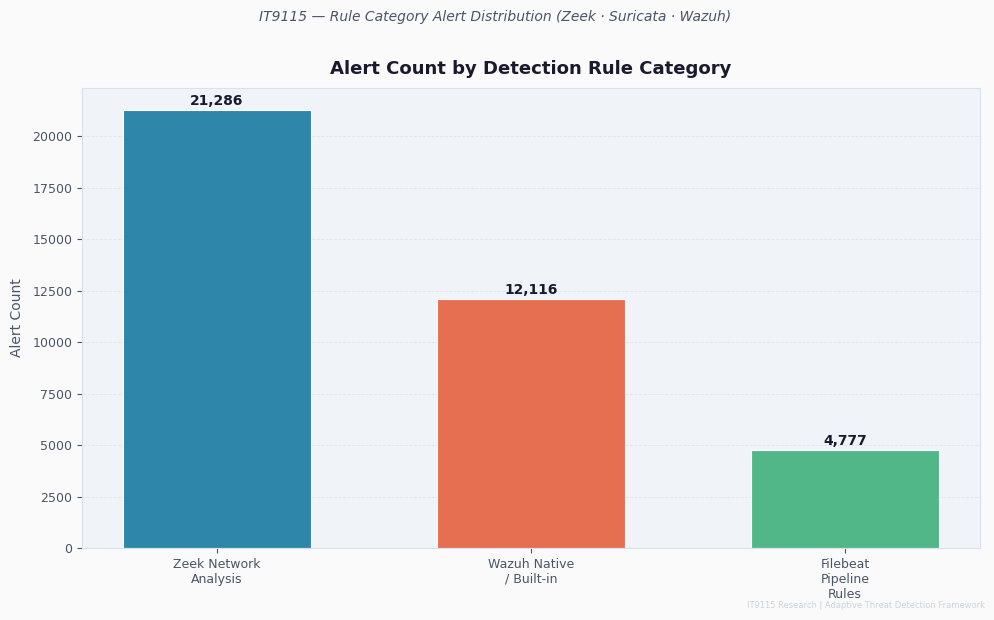

In [20]:
def fig6c_severity_rule_categories():
    by_cat = data.raw.get("rule_hits", {}).get("by_category", {})
    if not by_cat:
        print("No rule category data"); return

    cat_labels = list(by_cat.keys())
    cat_values = list(by_cat.values())
    cat_colors = [PALETTE["zeek"], PALETTE["suricata"], PALETTE["wazuh"],
                  PALETTE["detected"], "#BBBBCC"][:len(cat_labels)]

    fig, ax = plt.subplots(figsize=(10, 6), facecolor=PALETTE["bg"])
    bx   = range(len(cat_labels))
    bars = ax.bar(bx, cat_values, color=cat_colors,
                  edgecolor="white", linewidth=0.8, width=0.6)
    ax.set_xticks(list(bx))
    ax.set_xticklabels(
        [textwrap.fill(l, 13) for l in cat_labels],
        fontsize=9.5, color=PALETTE["text"])
    for bar, val in zip(bars, cat_values):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + max(cat_values) * 0.01,
                f"{val:,}", ha="center", fontsize=10,
                fontweight="bold", color=PALETTE["text"])
    _apply_style(ax, title="Alert Count by Detection Rule Category",
                 ylabel="Alert Count", grid_axis="y")

    fig.suptitle("IT9115 — Rule Category Alert Distribution (Zeek · Suricata · Wazuh)",
                 **FONT_SUPTITLE, y=1.01)
    _watermark(fig)
    _save(fig, "fig6c_severity_rule_categories")

fig6c_severity_rule_categories()

---
## Figure 7a — Alert Distribution by OSI Layer
Horizontal bars showing alert volume per OSI layer with legend.

  Saved: fig7a_osi_layer_bars.png   [254 KB  @300 dpi]


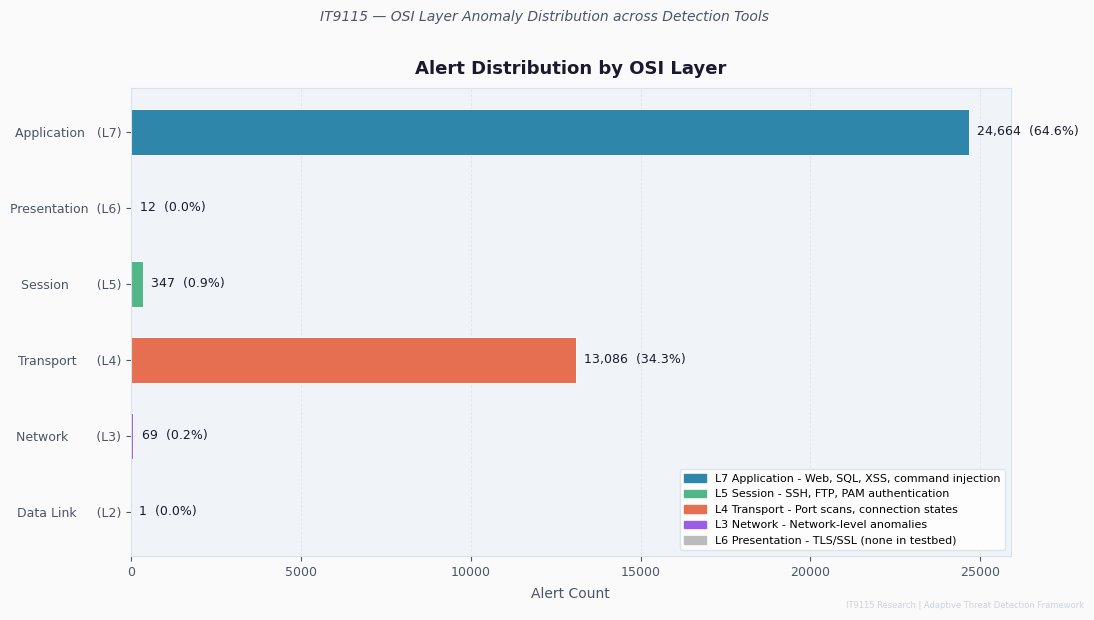

In [21]:
def fig7a_osi_layer_bars():
    osi = data.osi_breakdown
    if not osi:
        print("No OSI data"); return

    layer_names  = list(osi.keys())
    layer_counts = [osi[l]["count"] for l in layer_names]
    layer_pcts   = [osi[l]["pct"]   for l in layer_names]
    lcolor_map   = {
        "Application": PALETTE["l7"], "Presentation": PALETTE["l6"],
        "Session":     PALETTE["l5"], "Transport":    PALETTE["l4"],
        "Network":     PALETTE["l3"],
    }
    bar_colors = [next((v for k, v in lcolor_map.items() if k in ln), "#AAAAAA")
                  for ln in layer_names]

    fig, ax = plt.subplots(figsize=(11, 6), facecolor=PALETTE["bg"])
    y    = range(len(layer_names))
    bars = ax.barh(y, layer_counts, height=0.60, color=bar_colors,
                   edgecolor="white", linewidth=0.7)
    ax.set_yticks(list(y))
    ax.set_yticklabels(layer_names, fontsize=10, color=PALETTE["text"])
    ax.invert_yaxis()
    max_c = max(layer_counts) if layer_counts else 1
    for bar, cnt, pct in zip(bars, layer_counts, layer_pcts):
        if cnt > 0:
            ax.text(cnt + max_c * 0.01, bar.get_y() + bar.get_height() / 2,
                    f"{cnt:,}  ({pct:.1f}%)", va="center", fontsize=9, color=PALETTE["text"])
    _apply_style(ax, title="Alert Distribution by OSI Layer",
                 xlabel="Alert Count", grid_axis="x")

    osi_key = [
        ("L7 Application",  PALETTE["l7"], "Web, SQL, XSS, command injection"),
        ("L5 Session",      PALETTE["l5"], "SSH, FTP, PAM authentication"),
        ("L4 Transport",    PALETTE["l4"], "Port scans, connection states"),
        ("L3 Network",      PALETTE["l3"], "Network-level anomalies"),
        ("L6 Presentation", PALETTE["l6"], "TLS/SSL (none in testbed)"),
    ]
    patches = [mpatches.Patch(color=c, label=f"{l} - {d}") for l, c, d in osi_key]
    ax.legend(handles=patches, loc="lower right", fontsize=8,
              framealpha=0.88, edgecolor=PALETTE["grid"])

    fig.suptitle("IT9115 — OSI Layer Anomaly Distribution across Detection Tools",
                 **FONT_SUPTITLE, y=1.01)
    _watermark(fig)
    _save(fig, "fig7a_osi_layer_bars")

fig7a_osi_layer_bars()

## Figure 7b — OSI Layer Distribution (Pie)
Pie chart showing the percentage contribution of each OSI layer.

  Saved: fig7b_osi_pie.png   [232 KB  @300 dpi]


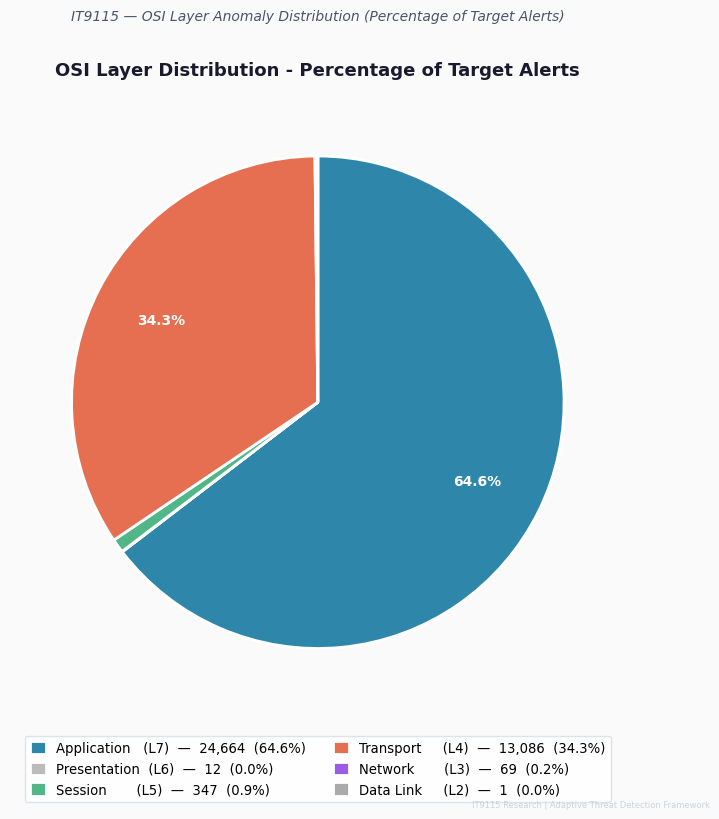

In [22]:
def fig7b_osi_pie():
    osi = data.osi_breakdown
    if not osi:
        print("No OSI data"); return

    layer_names  = list(osi.keys())
    layer_counts = [osi[l]["count"] for l in layer_names]
    lcolor_map   = {
        "Application": PALETTE["l7"], "Presentation": PALETTE["l6"],
        "Session":     PALETTE["l5"], "Transport":    PALETTE["l4"],
        "Network":     PALETTE["l3"],
    }
    bar_colors = [next((v for k, v in lcolor_map.items() if k in ln), "#AAAAAA")
                  for ln in layer_names]

    nz = [(layer_counts[i], bar_colors[i], layer_names[i])
          for i in range(len(layer_counts)) if layer_counts[i] > 0]
    if not nz:
        print("All OSI counts zero"); return
    nz_counts, nz_colors, nz_labels = zip(*nz)

    total = sum(nz_counts)

    # Only show percentage inside wedge if slice is large enough to fit text
    def _autopct(pct):
        return f"{pct:.1f}%" if pct >= 5 else ""

    fig, ax = plt.subplots(figsize=(8, 8), facecolor=PALETTE["bg"])
    ax.set_facecolor(PALETTE["panel"])

    # No inline labels — legend handles all annotation to avoid overlap
    wedges, _, autotexts = ax.pie(
        nz_counts, colors=nz_colors,
        autopct=_autopct,
        startangle=90, counterclock=False,
        wedgeprops=dict(edgecolor="white", linewidth=2.0),
        pctdistance=0.72)

    for at in autotexts:
        at.set_fontsize(10); at.set_color("white"); at.set_fontweight("bold")

    # Legend: layer name + count + percentage — no overlap possible
    legend_labels = [
        f"{lbl}  —  {cnt:,}  ({cnt/total*100:.1f}%)"
        for lbl, cnt in zip(nz_labels, nz_counts)
    ]
    ax.legend(wedges, legend_labels,
              loc="lower center", bbox_to_anchor=(0.5, -0.16),
              fontsize=9.5, framealpha=0.92, ncol=2,
              edgecolor=PALETTE["grid"], handlelength=1.2, handleheight=1.2)

    ax.set_title("OSI Layer Distribution - Percentage of Target Alerts",
                 **FONT_TITLE, pad=14)

    fig.suptitle("IT9115 — OSI Layer Anomaly Distribution (Percentage of Target Alerts)",
                 **FONT_SUPTITLE, y=1.01)
    _watermark(fig)
    _save(fig, "fig7b_osi_pie")

fig7b_osi_pie()

## Figure 7c — Alert Volume Reduction Waterfall
Raw alerts -> FP filter -> deduplication: progressive volume reduction.

  Saved: fig7c_alert_waterfall.png   [188 KB  @300 dpi]


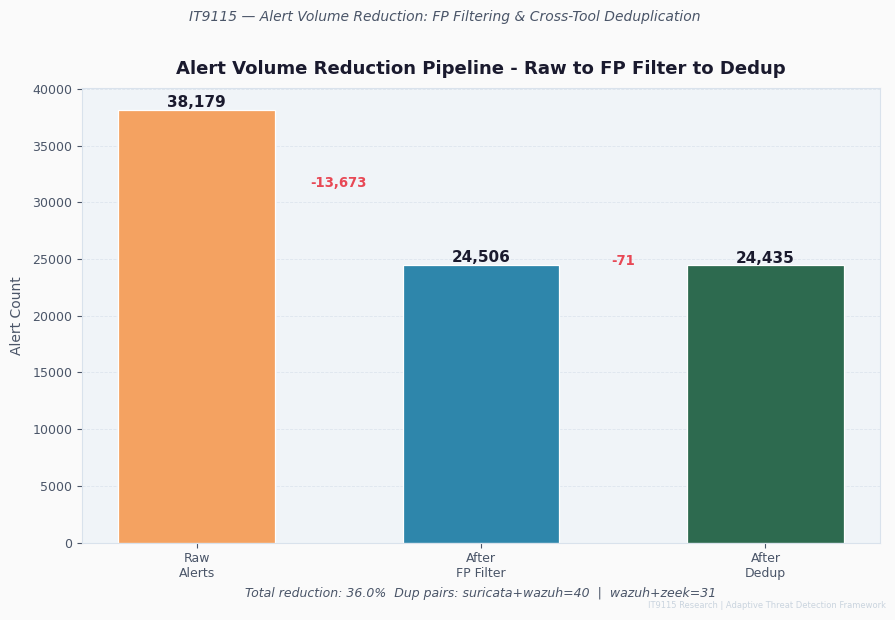

In [23]:
def fig7c_alert_waterfall():
    fp_data   = data.fp
    raw_total = fp_data.get("raw_alerts",       14386)
    fp_est    = fp_data.get("fp_count_used",    0)
    dup_ct    = fp_data.get("duplicate_alerts", 0)
    after_fp  = raw_total - fp_est
    after_dup = after_fp  - dup_ct
    by_pair   = data.raw.get("dedup", {}).get("by_tool_pair", {})

    wf_labels = ["Raw\nAlerts", "After\nFP Filter", "After\nDedup"]
    wf_values = [raw_total, after_fp, after_dup]
    wf_colors = [PALETTE["warning"], PALETTE["detected"], PALETTE["green"]]

    fig, ax = plt.subplots(figsize=(9, 6), facecolor=PALETTE["bg"])
    bx   = range(len(wf_labels))
    bars = ax.bar(bx, wf_values, color=wf_colors,
                  edgecolor="white", linewidth=0.9, width=0.55)
    ax.set_xticks(list(bx))
    ax.set_xticklabels(wf_labels, fontsize=11)
    for bar, val in zip(bars, wf_values):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + raw_total * 0.005,
                f"{val:,}", ha="center", fontsize=11,
                fontweight="bold", color=PALETTE["text"])
    for i in range(len(wf_values) - 1):
        red = wf_values[i] - wf_values[i + 1]
        ax.annotate(f"-{red:,}",
                    xy=(i + 0.5, (wf_values[i] + wf_values[i + 1]) / 2),
                    ha="center", fontsize=9.5, color=PALETTE["missed"],
                    fontweight="bold")
    _apply_style(ax, title="Alert Volume Reduction Pipeline - Raw to FP Filter to Dedup",
                 ylabel="Alert Count", grid_axis="y")

    vol_red = fp_data.get("total_volume_reduction_pct", 0)
    pair_str = "  |  ".join(f"{k}={v}" for k, v in by_pair.items()) if by_pair else ""
    ax.text(0.5, -0.12,
            f"Total reduction: {vol_red:.1f}%  " + (f"Dup pairs: {pair_str}" if pair_str else ""),
            ha="center", transform=ax.transAxes, fontsize=9,
            color=PALETTE["subtext"], fontstyle="italic")

    fig.suptitle("IT9115 — Alert Volume Reduction: FP Filtering & Cross-Tool Deduplication",
                 **FONT_SUPTITLE, y=1.01)
    _watermark(fig)
    _save(fig, "fig7c_alert_waterfall")

fig7c_alert_waterfall()

---
## Figure 8a — Alert Volume per Sensor Tool
Bar chart comparing Zeek (NSM), Suricata (IDS), and Wazuh (HIDS).

  Saved: fig8a_tool_alert_volume.png   [163 KB  @300 dpi]


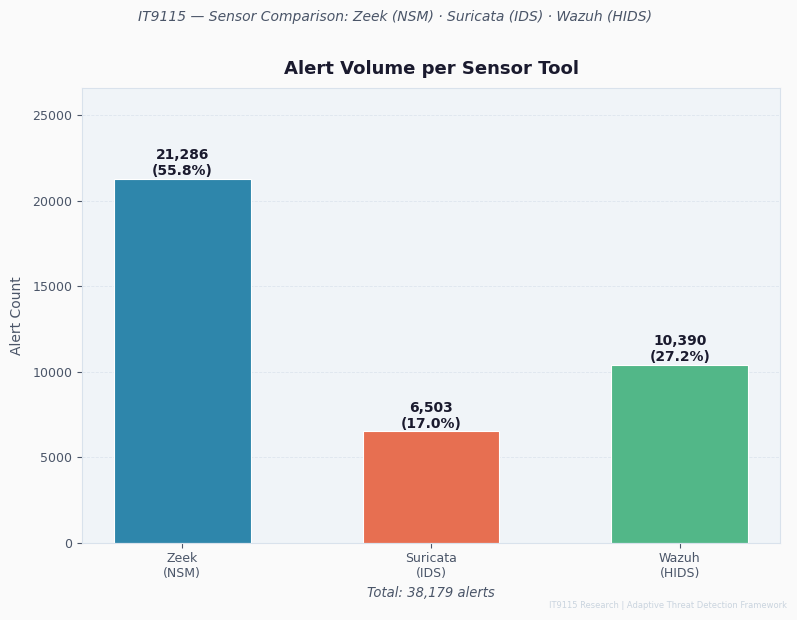

In [24]:
def fig8a_tool_alert_volume():
    src   = data.sources
    z_ct  = src.get("zeek",         0)
    s_ct  = src.get("suricata",     0)
    w_ct  = src.get("wazuh_native", 0)
    total = src.get("total", z_ct + s_ct + w_ct) or 1

    tool_names = ["Zeek\n(NSM)", "Suricata\n(IDS)", "Wazuh\n(HIDS)"]
    volumes    = [z_ct, s_ct, w_ct]
    t_colors   = [PALETTE["zeek"], PALETTE["suricata"], PALETTE["wazuh"]]

    fig, ax = plt.subplots(figsize=(8, 6), facecolor=PALETTE["bg"])
    bars = ax.bar(tool_names, volumes, color=t_colors,
                  edgecolor="white", linewidth=0.8, width=0.55)
    max_v = max(volumes) or 1
    for bar, vol in zip(bars, volumes):
        pct = vol / total * 100
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + max_v * 0.01,
                f"{vol:,}\n({pct:.1f}%)",
                ha="center", fontsize=10, fontweight="bold",
                color=PALETTE["text"], multialignment="center")
    ax.set_ylim(0, max_v * 1.25)
    _apply_style(ax, title="Alert Volume per Sensor Tool",
                 ylabel="Alert Count", grid_axis="y")
    ax.text(0.5, -0.12, f"Total: {total:,} alerts",
            ha="center", transform=ax.transAxes, fontsize=9.5,
            color=PALETTE["subtext"], fontstyle="italic")

    fig.suptitle("IT9115 — Sensor Comparison: Zeek (NSM) · Suricata (IDS) · Wazuh (HIDS)",
                 **FONT_SUPTITLE, y=1.01)
    _watermark(fig)
    _save(fig, "fig8a_tool_alert_volume")

fig8a_tool_alert_volume()

## Figure 8b — Sensor Tool Capability Radar
Normalised radar chart comparing five capability dimensions across all three tools.

  Saved: fig8b_tool_radar.png   [452 KB  @300 dpi]


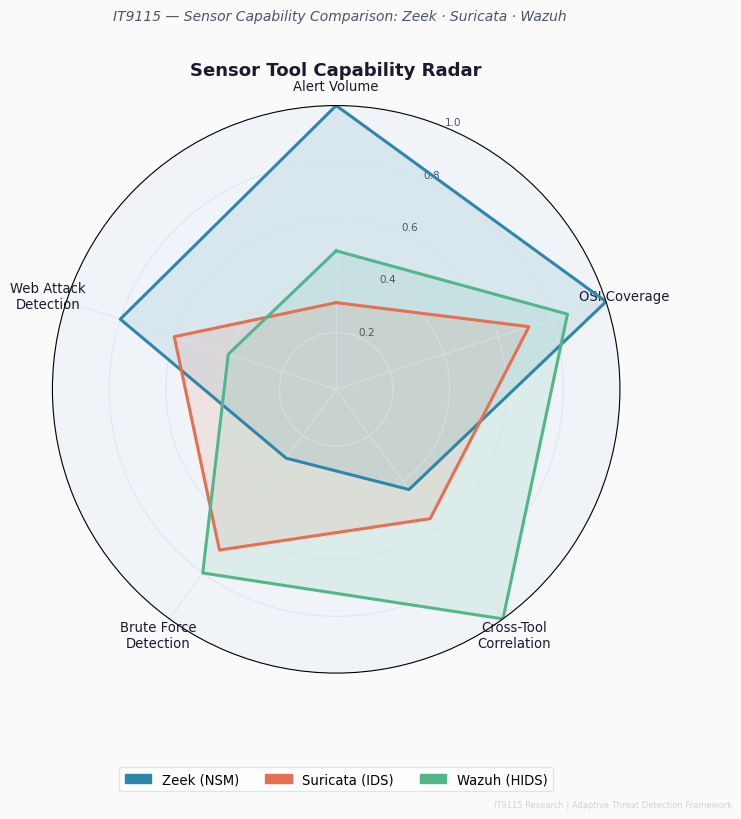

In [25]:
def fig8b_tool_radar():
    src   = data.sources
    z_ct  = src.get("zeek",         0)
    s_ct  = src.get("suricata",     0)
    w_ct  = src.get("wazuh_native", 0)
    max_alerts = max(z_ct, s_ct, w_ct) or 1

    dedup        = data.raw.get("dedup", {}).get("by_tool_pair", {})
    dup_zeek     = dedup.get("wazuh+zeek",    0) + dedup.get("suricata+zeek",  0)
    dup_suricata = dedup.get("suricata+wazuh",0) + dedup.get("suricata+zeek",  0)
    dup_wazuh    = dedup.get("wazuh+zeek",    0) + dedup.get("suricata+wazuh", 0)
    max_dup = max(dup_zeek, dup_suricata, dup_wazuh) or 1

    radar_attrs = ["Alert Volume", "OSI Coverage", "Cross-Tool\nCorrelation",
                   "Brute Force\nDetection", "Web Attack\nDetection"]
    tool_radar = {
        "Zeek (NSM)":     [z_ct/max_alerts, 7/7, dup_zeek/max_dup,     0.30, 0.80],
        "Suricata (IDS)": [s_ct/max_alerts, 5/7, dup_suricata/max_dup, 0.70, 0.60],
        "Wazuh (HIDS)":   [w_ct/max_alerts, 6/7, dup_wazuh/max_dup,    0.80, 0.40],
    }
    tool_colors = [PALETTE["zeek"], PALETTE["suricata"], PALETTE["wazuh"]]

    N      = len(radar_attrs)
    angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
    angles += angles[:1]

    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True),
                            facecolor=PALETTE["bg"])
    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(radar_attrs, size=9.5, color=PALETTE["text"])
    ax.set_ylim(0, 1)
    ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
    ax.set_yticklabels(["0.2","0.4","0.6","0.8","1.0"], size=7.5, color=PALETTE["subtext"])
    ax.grid(color=PALETTE["grid"], linewidth=0.9, alpha=0.65)
    ax.set_facecolor(PALETTE["panel"])
    ax.set_title("Sensor Tool Capability Radar", pad=22, **FONT_TITLE)

    for (tool, values), col in zip(tool_radar.items(), tool_colors):
        vals = values + values[:1]
        ax.plot(angles, vals, color=col, linewidth=2.2, linestyle="solid")
        ax.fill(angles, vals, color=col, alpha=0.12)

    legend_handles = [mpatches.Patch(color=c, label=t)
                      for t, c in zip(tool_radar.keys(), tool_colors)]
    ax.legend(handles=legend_handles, loc="lower center",
              bbox_to_anchor=(0.5, -0.22), fontsize=9.5, ncol=3,
              framealpha=0.9, edgecolor=PALETTE["grid"])

    fig.suptitle("IT9115 — Sensor Capability Comparison: Zeek · Suricata · Wazuh",
                 **FONT_SUPTITLE, y=1.01)
    _watermark(fig)
    _save(fig, "fig8b_tool_radar")

fig8b_tool_radar()

## Figure 8c — Cross-Tool Correlation Summary
Summary panel of multi-tool correlation stats, kill-chain alerts, and top correlated source.

  Saved: fig8c_cross_tool_correlation.png   [159 KB  @300 dpi]


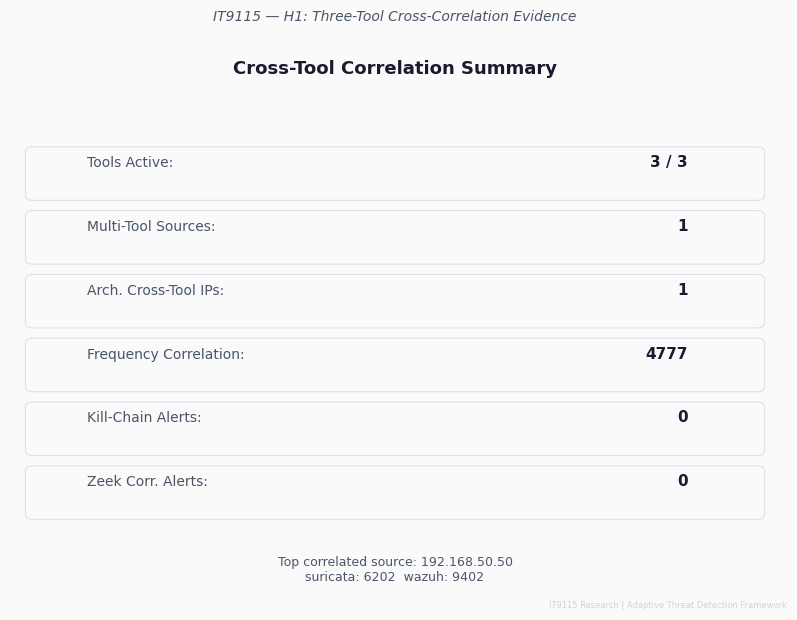

In [26]:
def fig8c_cross_tool_correlation():
    ct_ev    = data.correlation.get("cross_tool_evidence", {})
    arch_ct  = data.correlation.get("arch_cross_tool_sources", 0)
    multi_ct = ct_ev.get("multi_tool_sources", 0)
    top_srcs = ct_ev.get("top_sources", [])
    corr_sum = data.correlation.get("summary", {})

    corr_info = [
        ("Tools Active",           "3 / 3"),
        ("Multi-Tool Sources",     str(multi_ct)),
        ("Arch. Cross-Tool IPs",   str(arch_ct)),
        ("Frequency Correlation",  str(corr_sum.get("frequency_correlation", 0))),
        ("Kill-Chain Alerts",      str(corr_sum.get("kill_chain_detection",  0))),
        ("Zeek Corr. Alerts",      str(corr_sum.get("zeek_correlation",      0))),
    ]

    fig, ax = plt.subplots(figsize=(8, 6), facecolor=PALETTE["bg"])
    ax.set_facecolor(PALETTE["panel"])
    ax.axis("off")
    ax.set_title("Cross-Tool Correlation Summary", **FONT_TITLE, pad=12)

    y_pos = 0.85
    for label, value in corr_info:
        ax.add_patch(FancyBboxPatch(
            (0.03, y_pos - 0.055), 0.94, 0.085,
            boxstyle="round,pad=0.01", facecolor=PALETTE["bg"],
            edgecolor=PALETTE["grid"], linewidth=0.8,
            transform=ax.transAxes))
        ax.text(0.10, y_pos, f"{label}:", ha="left", fontsize=10,
                color=PALETTE["subtext"], transform=ax.transAxes)
        ax.text(0.88, y_pos, value, ha="right", fontsize=11,
                fontweight="bold", color=PALETTE["text"], transform=ax.transAxes)
        y_pos -= 0.125

    if top_srcs:
        src0 = top_srcs[0]
        tc   = "  ".join(f"{t}: {c}" for t, c in src0.get("tool_counts", {}).items())
        ax.text(0.5, 0.04,
                f"Top correlated source: {src0.get('source_ip','')}\n{tc}",
                ha="center", fontsize=9, color=PALETTE["subtext"],
                transform=ax.transAxes, multialignment="center")

    fig.suptitle("IT9115 — H1: Three-Tool Cross-Correlation Evidence",
                 **FONT_SUPTITLE, y=1.01)
    _watermark(fig)
    _save(fig, "fig8c_cross_tool_correlation")

fig8c_cross_tool_correlation()

## Figure 8d — Alert Count per Sensor Tool x OSI Layer
Grouped bars showing how each sensor contributes to each OSI layer.

  Saved: fig8d_tool_osi_attribution.png   [174 KB  @300 dpi]


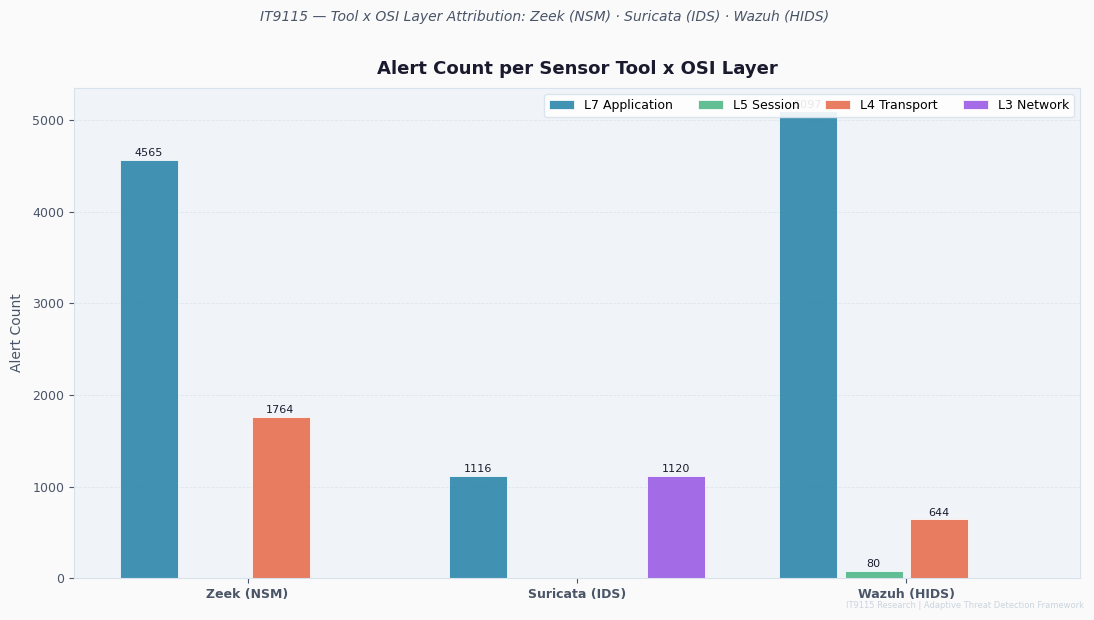

In [27]:
def fig8d_tool_osi_attribution():
    tool_osi = {
        "Zeek (NSM)":     {"L7": 4565, "L4": 1764, "L3":    0, "L5":   0},
        "Suricata (IDS)": {"L7": 1116, "L4":    0, "L3": 1120, "L5":   0},
        "Wazuh (HIDS)":   {"L7": 5097, "L4":  644, "L3":    0, "L5":  80},
    }
    osi_layers  = ["L7 Application", "L5 Session", "L4 Transport", "L3 Network"]
    osi_colors2 = [PALETTE["l7"], PALETTE["l5"], PALETTE["l4"], PALETTE["l3"]]
    tools_btm   = list(tool_osi.keys())
    x_btm = np.arange(len(tools_btm))
    width = 0.20
    offsets = [-1.5, -0.5, 0.5, 1.5]

    fig, ax = plt.subplots(figsize=(11, 6), facecolor=PALETTE["bg"])
    for (layer, col), off in zip(zip(osi_layers, osi_colors2), offsets):
        key  = layer.split()[0]
        vals = [tool_osi[t].get(key, 0) for t in tools_btm]
        bars = ax.bar(x_btm + off * width, vals, width * 0.88,
                      label=layer, color=col, edgecolor="white",
                      linewidth=0.6, alpha=0.90)
        for bar, v in zip(bars, vals):
            if v > 0:
                ax.text(bar.get_x() + bar.get_width() / 2,
                        bar.get_height() + 40, str(v),
                        ha="center", fontsize=8, color=PALETTE["text"])

    ax.set_xticks(x_btm)
    ax.set_xticklabels(tools_btm, fontsize=11, fontweight="bold",
                       color=PALETTE["text"])
    _apply_style(ax, title="Alert Count per Sensor Tool x OSI Layer",
                 ylabel="Alert Count", grid_axis="y")
    ax.legend(fontsize=9, framealpha=0.9, edgecolor=PALETTE["grid"],
              loc="upper right", ncol=4)

    fig.suptitle(
        "IT9115 — Tool x OSI Layer Attribution: Zeek (NSM) · Suricata (IDS) · Wazuh (HIDS)",
        **FONT_SUPTITLE, y=1.01)
    _watermark(fig)
    _save(fig, "fig8d_tool_osi_attribution")

fig8d_tool_osi_attribution()

---
## Output Summary
Run the cell below to list all generated figures with file sizes.

In [28]:
from pathlib import Path

print("=" * 65)
print("  IT9115 — Individual Chart Export Summary")
print("=" * 65)
pngs = sorted(Path(OUTPUT_DIR).glob("*.png"))
total_kb = 0
for p in pngs:
    kb = p.stat().st_size // 1024
    total_kb += kb
    print(f"  {p.name:<48}  {kb:>5} KB")
print("-" * 65)
print(f"  {len(pngs)} figures  |  {total_kb:,} KB total  |  {DPI} dpi")
print(f"  Output: {Path(OUTPUT_DIR).resolve()}")
print("=" * 65)

  IT9115 — Individual Chart Export Summary
  fig1a_mitre_technique_bars.png                      344 KB
  fig1b_mitre_coverage_donut.png                      203 KB
  fig2a_confusion_matrix.png                          232 KB
  fig2b_precision_recall_cards.png                    148 KB
  fig3a_attack_coverage_bars.png                      312 KB
  fig3b_attack_coverage_table.png                     273 KB
  fig4a_mttd_lollipop.png                             650 KB
  fig4b_mttd_histogram.png                            167 KB
  fig5a_mttc_soar_bars.png                            150 KB
  fig5b_mttc_gauge.png                                160 KB
  fig5c_mttc_pipeline.png                             141 KB
  fig6a_severity_donut.png                            176 KB
  fig6b_severity_bars.png                             128 KB
  fig6c_severity_rule_categories.png                  162 KB
  fig7a_osi_layer_bars.png                            254 KB
  fig7b_osi_pie.png                       